# Projeto C318 - Classificação de Faixas Salariais no Mercado de IA

**Objetivo**: Desenvolver um modelo preditivo para classificar vagas na área de IA/dados em diferentes faixas de salário anual.

**Tipo de Problema**: Classificação Multiclasse

**Variável Alvo**: `salary`, discretizada em três classes: `Baixo`, `Médio` e `Alto`

---

## Sumário

1. Configuração e Reprodutibilidade
2. Carregamento dos Dados
3. Análise Exploratória (EDA)
4. Pré-processamento
5. Modelagem Supervisionada
6. Otimização de Hiperparâmetros
7. Modelagem Não Supervisionada
8. Conclusões


---
## 1. Configuração e Reprodutibilidade

In [248]:

# ============================================================
# SEED GLOBAL - Garantir reprodutibilidade
# ============================================================
SEED = 67

import random
import numpy as np

random.seed(SEED)
np.random.seed(SEED)

# ============================================================
# Imports
# ============================================================

import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import joblib
import os
import pandas as pd


# Scikit-learn
from sklearn.metrics import silhouette_score
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, StratifiedKFold
from statsmodels.tools.tools import add_constant
from sklearn.preprocessing import StandardScaler, OrdinalEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.cluster import KMeans
# Curva ROC One-vs-Rest (OvR)
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

from sklearn.cluster import KMeans
from sklearn.pipeline import Pipeline
from sklearn.base import BaseEstimator, TransformerMixin


from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score, 
    balanced_accuracy_score, 
    precision_score, 
    recall_score, 
    f1_score,
    classification_report, 
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    auc
)

# XGBoost
from xgboost import XGBRegressor

# Statsmodels para VIF
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Otimização Bayesiana
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)
import time

# Configurações
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
plt.style.use('seaborn-v0_8-whitegrid')
%matplotlib inline

print("Configuração concluída!")
print(f"Seed global: {SEED}")

Configuração concluída!
Seed global: 67


---
## 2. Carregamento dos Dados

In [249]:
# Carregar dataset
df = pd.read_csv('../data/AI Job Market Dataset.csv')

print(f"Shape: {df.shape}")
print(f"Linhas: {df.shape[0]:,}")
print(f"Colunas: {df.shape[1]}")

Shape: (10345, 19)
Linhas: 10,345
Colunas: 19


In [250]:
# Visualizar primeiras linhas
df.head(10)

,job_id,job_title,company_size,company_industry,country,remote_type,experience_level,years_experience,education_level,skills_python,skills_sql,skills_ml,skills_deep_learning,skills_cloud,salary,job_posting_month,job_posting_year,hiring_urgency,job_openings
0,1,AI Engineer,Startup,Retail,Canada,Remote,Senior,2,Master,0,0,0,1,0,158322,6,2024,Low,4
1,2,Machine Learning Engineer,MNC,Technology,Australia,Hybrid,Mid,0,Bachelor,1,1,1,0,1,163666,11,2026,High,9
2,3,Machine Learning Engineer,MNC,Technology,Germany,Onsite,Mid,14,Master,1,0,1,0,1,158556,3,2026,High,9
3,4,Business Analyst,Startup,Healthcare,Germany,Remote,Mid,9,Master,0,1,0,1,1,95775,3,2025,High,7
4,5,Data Scientist,MNC,Healthcare,Germany,Hybrid,Mid,5,Master,1,1,1,0,0,111873,12,2021,Low,2
5,6,Machine Learning Engineer,Medium,Technology,Australia,Onsite,Senior,6,Master,1,0,1,1,0,165878,5,2021,High,2
6,7,Data Scientist,MNC,Technology,Germany,Remote,Entry,14,Bachelor,0,0,0,0,0,67027,8,2026,High,8
7,8,Data Analyst,Enterprise,Finance,UK,Onsite,Entry,4,PhD,1,0,1,0,1,78392,8,2023,High,7
8,9,Machine Learning Engineer,Startup,Education,Canada,Onsite,Mid,2,PhD,0,0,0,0,1,123840,5,2021,Low,3
9,10,Data Engineer,Enterprise,Retail,USA,Onsite,Senior,9,Master,1,0,0,0,1,112408,4,2024,High,7


In [251]:
# Informações do dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10345 entries, 0 to 10344
Data columns (total 19 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   job_id                10345 non-null  int64 
 1   job_title             10345 non-null  object
 2   company_size          10345 non-null  object
 3   company_industry      10345 non-null  object
 4   country               10345 non-null  object
 5   remote_type           10345 non-null  object
 6   experience_level      10345 non-null  object
 7   years_experience      10345 non-null  int64 
 8   education_level       10345 non-null  object
 9   skills_python         10345 non-null  int64 
 10  skills_sql            10345 non-null  int64 
 11  skills_ml             10345 non-null  int64 
 12  skills_deep_learning  10345 non-null  int64 
 13  skills_cloud          10345 non-null  int64 
 14  salary                10345 non-null  int64 
 15  job_posting_month     10345 non-null

In [252]:
# Estatísticas descritivas
df.describe()

,job_id,years_experience,skills_python,skills_sql,skills_ml,skills_deep_learning,skills_cloud,salary,job_posting_month,job_posting_year,job_openings
count,10345.000000,10345.000000,10345.000000,10345.000000,10345.000000,10345.000000,10345.000000,10345.00000,10345.000000,10345.000000,10345.00000
mean,5173.000000,6.950507,0.493088,0.503045,0.507878,0.498018,0.511455,113438.22726,6.502465,2023.000387,5.00406
std,2986.488601,4.320054,0.499976,0.500015,0.499962,0.500020,0.499893,31389.20106,3.473441,1.996856,2.58382
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,45083.00000,1.000000,2020.000000,1.00000
25%,2587.000000,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,89715.00000,4.000000,2021.000000,3.00000
50%,5173.000000,7.000000,0.000000,1.000000,1.000000,0.000000,1.000000,113082.00000,6.000000,2023.000000,5.00000
75%,7759.000000,11.000000,1.000000,1.000000,1.000000,1.000000,1.000000,134894.00000,10.000000,2025.000000,7.00000
max,10345.000000,14.000000,1.000000,1.000000,1.000000,1.000000,1.000000,204143.00000,12.000000,2026.000000,9.00000


---
## 3. Análise Exploratória de Dados (EDA)

### 3.1 Verificação de Valores Faltantes

In [253]:
# talvez colocar um heatmap?
# Valores faltantes
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)

missing_df = pd.DataFrame({
    'Faltantes': missing,
    'Percentual (%)': missing_pct
})

print("Valores Faltantes por Coluna:")
print(missing_df[missing_df['Faltantes'] > 0] if missing.sum() > 0 else "Nenhum valor faltante!")

Valores Faltantes por Coluna:
Nenhum valor faltante!


### 3.2 Análise da Variável Alvo (salary)

In [254]:
# Estatísticas do salary
print("Estatísticas do Salário:")
print(f"  Mínimo:  ${df['salary'].min():,.0f}")
print(f"  Máximo:  ${df['salary'].max():,.0f}")
print(f"  Média:   ${df['salary'].mean():,.0f}")
print(f"  Mediana: ${df['salary'].median():,.0f}")
print(f"  Desvio:  ${df['salary'].std():,.0f}")

Estatísticas do Salário:
  Mínimo:  $45,083
  Máximo:  $204,143
  Média:   $113,438
  Mediana: $113,082
  Desvio:  $31,389


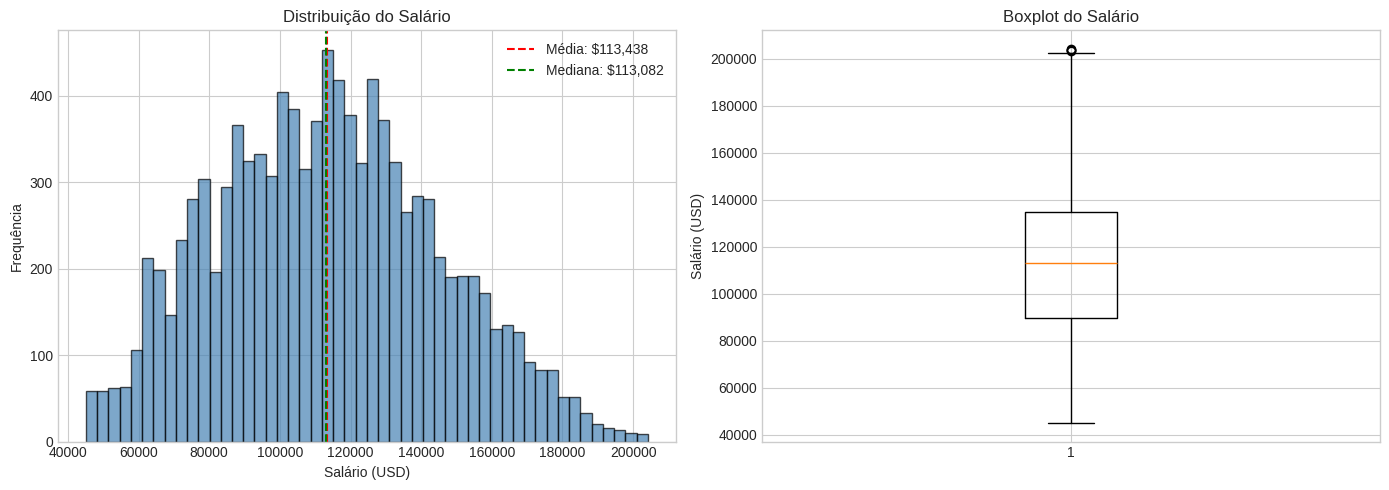

In [255]:
# Distribuição do salary
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma
axes[0].hist(df['salary'], bins=50, edgecolor='black', alpha=0.7, color='steelblue')
axes[0].set_xlabel('Salário (USD)')
axes[0].set_ylabel('Frequência')
axes[0].set_title('Distribuição do Salário')
axes[0].axvline(df['salary'].mean(), color='red', linestyle='--', label=f"Média: ${df['salary'].mean():,.0f}")
axes[0].axvline(df['salary'].median(), color='green', linestyle='--', label=f"Mediana: ${df['salary'].median():,.0f}")
axes[0].legend()

# Boxplot
axes[1].boxplot(df['salary'], vert=True)
axes[1].set_ylabel('Salário (USD)')
axes[1].set_title('Boxplot do Salário')

plt.tight_layout()
plt.savefig('../reports/salary_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

### 3.3 Análise das Variáveis Categóricas

In [256]:
# Variáveis categóricas
cat_cols = ['job_title', 'company_size', 'company_industry', 'country', 
            'remote_type', 'experience_level', 'education_level', 'hiring_urgency']

print("Valores únicos por variável categórica:")
for col in cat_cols:
    print(f"\n{col}:")
    print(df[col].value_counts())

Valores únicos por variável categórica:

job_title:
job_title
Business Analyst             1773
AI Engineer                  1742
Machine Learning Engineer    1740
Data Analyst                 1711
Data Scientist               1703
Data Engineer                1676
Name: count, dtype: int64

company_size:
company_size
Startup       2656
MNC           2593
Medium        2548
Enterprise    2548
Name: count, dtype: int64

company_industry:
company_industry
Technology    1787
E-commerce    1744
Finance       1724
Healthcare    1715
Education     1704
Retail        1671
Name: count, dtype: int64

country:
country
Germany      1498
Singapore    1490
Canada       1488
UK           1485
India        1470
USA          1459
Australia    1455
Name: count, dtype: int64

remote_type:
remote_type
Remote    3513
Hybrid    3420
Onsite    3412
Name: count, dtype: int64

experience_level:
experience_level
Entry     3513
Senior    3420
Mid       3412
Name: count, dtype: int64

education_level:
education_

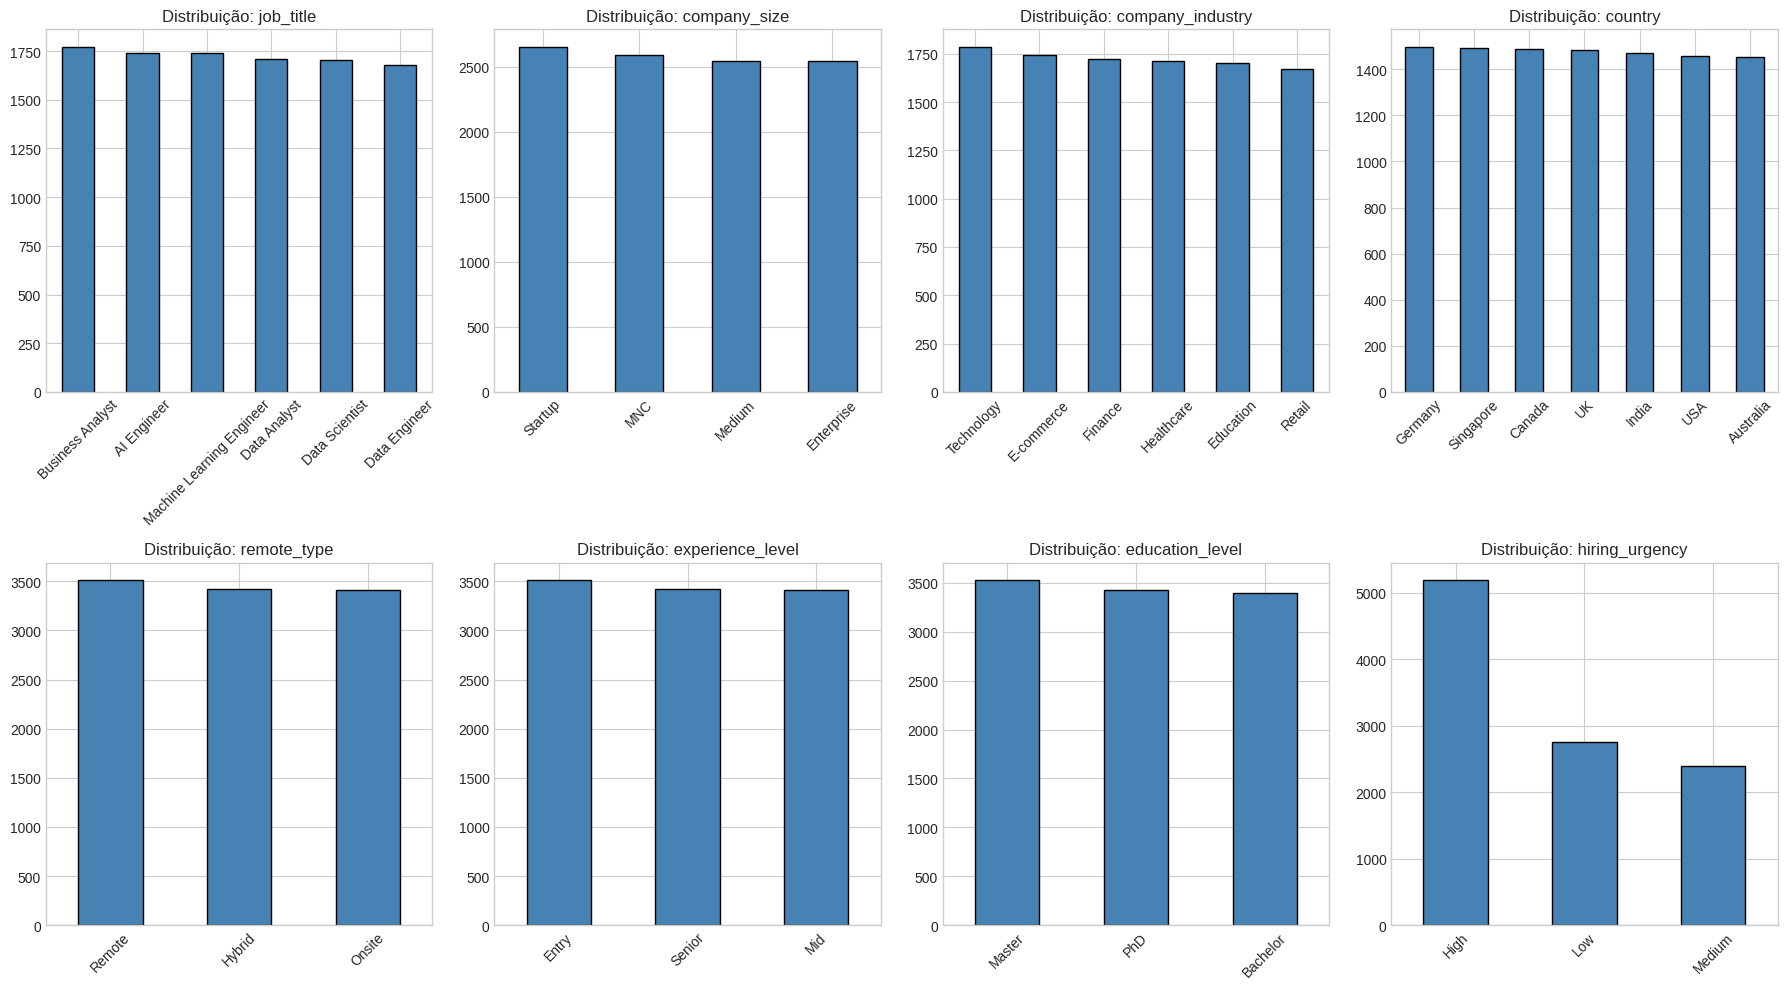

In [257]:
# Gráficos de barras para variáveis categóricas
fig, axes = plt.subplots(2, 4, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    df[col].value_counts().plot(kind='bar', ax=axes[i], color='steelblue', edgecolor='black')
    axes[i].set_title(f'Distribuição: {col}')
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('../reports/categorical_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

### 3.4 Salário por Categoria

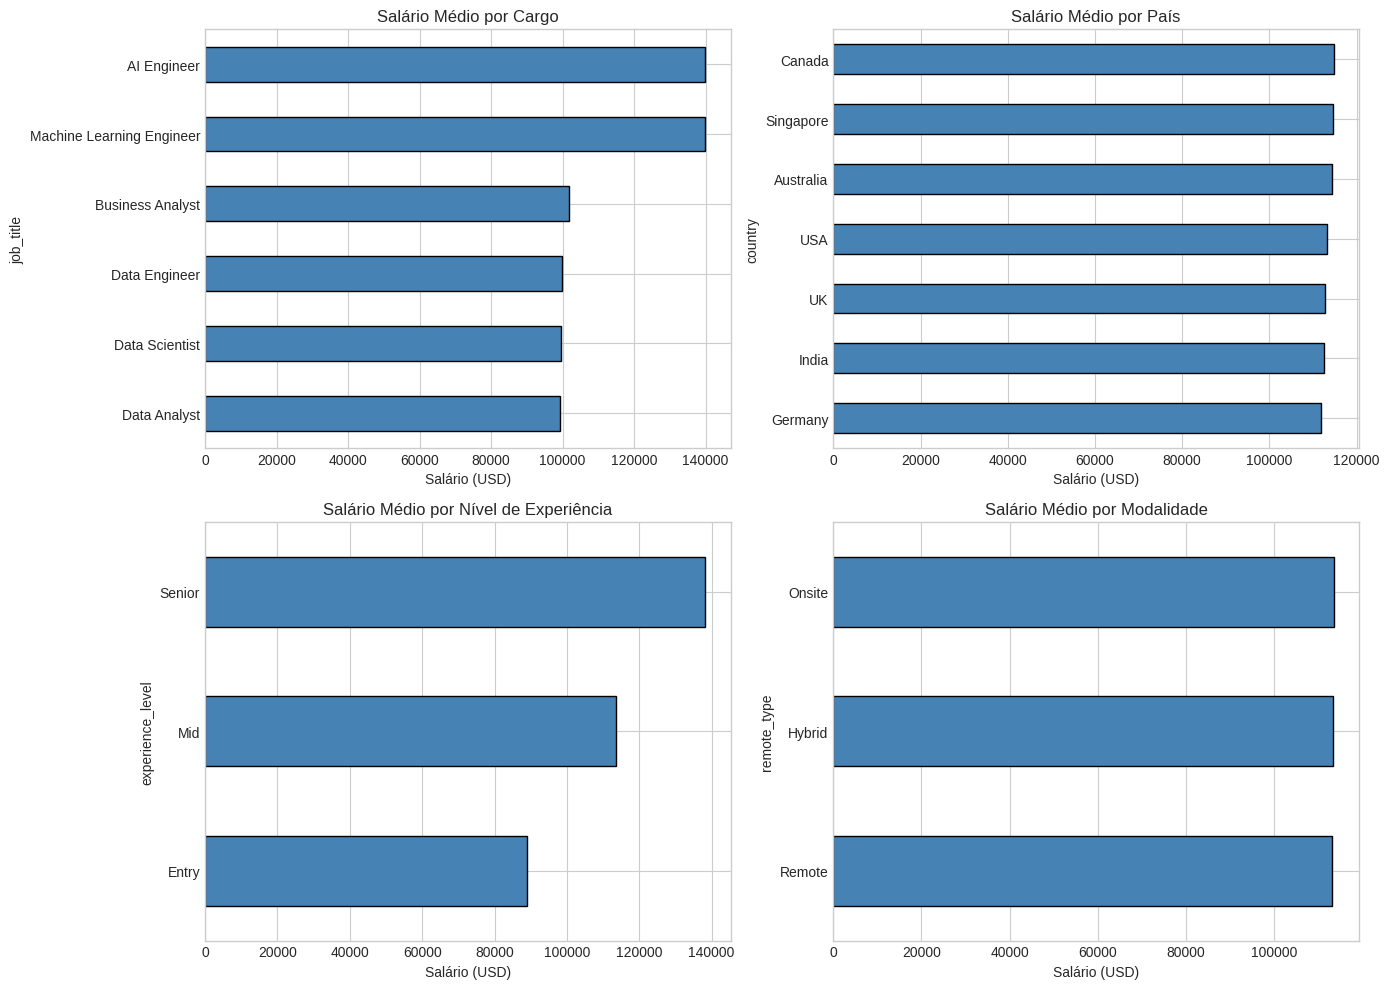

In [258]:
    # Salário médio por job_title
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    # Por cargo
    df.groupby('job_title')['salary'].mean().sort_values(ascending=True).plot(
        kind='barh', ax=axes[0, 0], color='steelblue', edgecolor='black')
    axes[0, 0].set_title('Salário Médio por Cargo')
    axes[0, 0].set_xlabel('Salário (USD)')

    # Por país
    df.groupby('country')['salary'].mean().sort_values(ascending=True).plot(
        kind='barh', ax=axes[0, 1], color='steelblue', edgecolor='black')
    axes[0, 1].set_title('Salário Médio por País')
    axes[0, 1].set_xlabel('Salário (USD)')

    # Por nível de experiência
    df.groupby('experience_level')['salary'].mean().sort_values(ascending=True).plot(
        kind='barh', ax=axes[1, 0], color='steelblue', edgecolor='black')
    axes[1, 0].set_title('Salário Médio por Nível de Experiência')
    axes[1, 0].set_xlabel('Salário (USD)')

    # Por modalidade de trabalho
    df.groupby('remote_type')['salary'].mean().sort_values(ascending=True).plot(
        kind='barh', ax=axes[1, 1], color='steelblue', edgecolor='black')
    axes[1, 1].set_title('Salário Médio por Modalidade')
    axes[1, 1].set_xlabel('Salário (USD)')

    plt.tight_layout()
    plt.savefig('../reports/salary_by_category.png', dpi=150, bbox_inches='tight')
    plt.show()

### 3.5 Análise das Skills

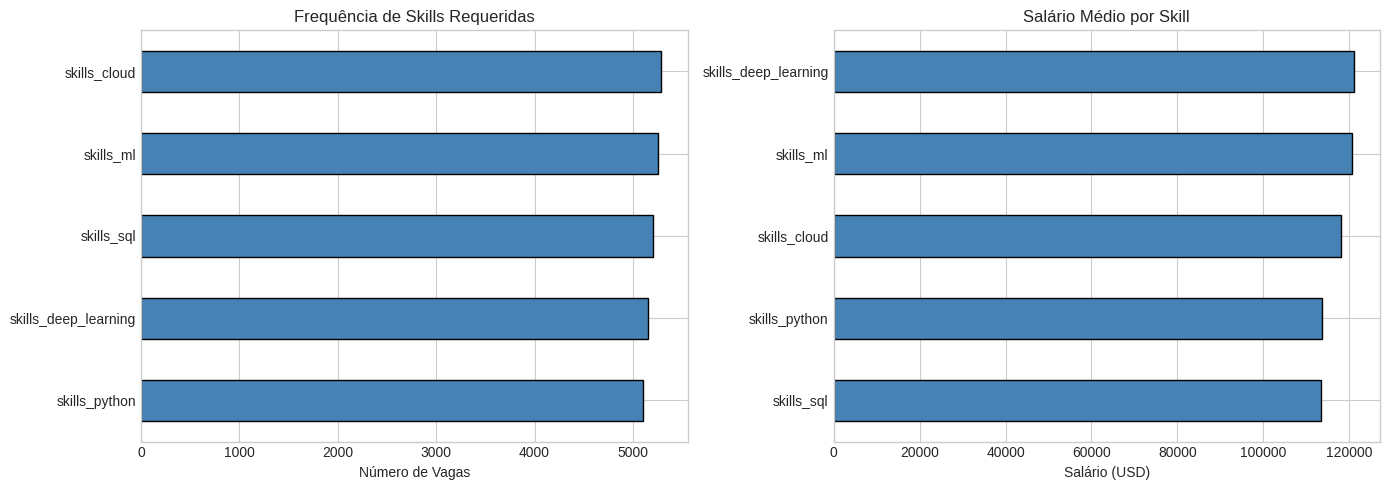

In [259]:
# Skills binárias
skills_cols = ['skills_python', 'skills_sql', 'skills_ml', 'skills_deep_learning', 'skills_cloud']

# Frequência de cada skill
skills_freq = df[skills_cols].sum().sort_values(ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Frequência
skills_freq.plot(kind='barh', ax=axes[0], color='steelblue', edgecolor='black')
axes[0].set_title('Frequência de Skills Requeridas')
axes[0].set_xlabel('Número de Vagas')

# Impacto no salário
skill_salary = {}
for skill in skills_cols:
    skill_salary[skill] = df[df[skill] == 1]['salary'].mean()

pd.Series(skill_salary).sort_values(ascending=True).plot(
    kind='barh', ax=axes[1], color='steelblue', edgecolor='black')
axes[1].set_title('Salário Médio por Skill')
axes[1].set_xlabel('Salário (USD)')

plt.tight_layout()
plt.savefig('../reports/skills_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

### 3.6 Matriz de Correlação

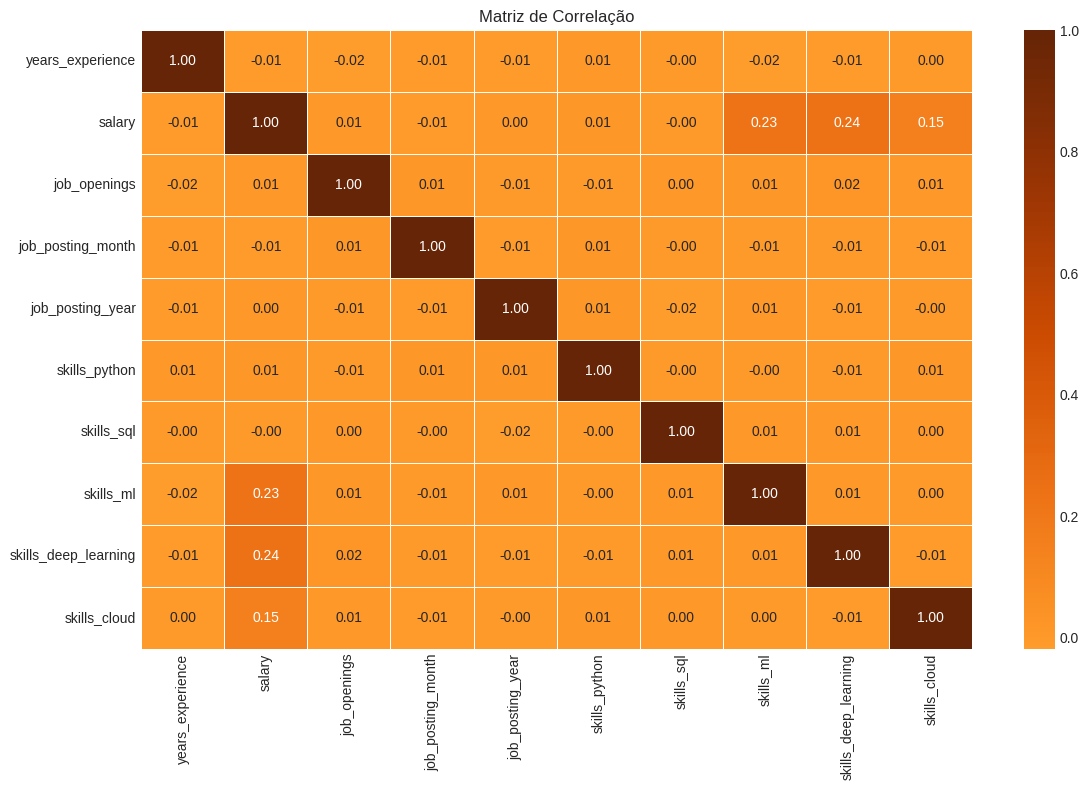

In [260]:
# Selecionar apenas colunas numéricas
numeric_cols = ['years_experience', 'salary', 'job_openings', 'job_posting_month', 'job_posting_year'] + skills_cols

# Matriz de correlação
corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap='YlOrBr', center=0, fmt='.2f', linewidths=0.5)
plt.title('Matriz de Correlação')
plt.tight_layout()
plt.savefig('../reports/correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

### 3.7 Análise de Duplicatas

In [261]:
# Verificar duplicatas
duplicatas_total = df.duplicated().sum()
duplicatas_sem_id = df.drop(columns=['job_id']).duplicated().sum()

print("Análise de Duplicatas:")
print(f"  Linhas duplicadas (todas as colunas): {duplicatas_total}")
print(f"  Linhas duplicadas (excluindo job_id): {duplicatas_sem_id}")

if duplicatas_sem_id > 0:
    print(f"\n  ATENÇÃO: {duplicatas_sem_id} linhas duplicadas encontradas!")
    print("  Exemplos de duplicatas:")
    duplicadas = df[df.drop(columns=['job_id']).duplicated(keep=False)]
    print(duplicadas.head(10))
else:
    print("\n  ✓ Nenhuma duplicata encontrada no dataset.")

Análise de Duplicatas:
  Linhas duplicadas (todas as colunas): 0
  Linhas duplicadas (excluindo job_id): 0

  ✓ Nenhuma duplicata encontrada no dataset.


### 3.8 Análise de Outliers

Análise de Outliers (Método IQR):
         Variável  Outliers % do Total Limite Inferior Limite Superior
 years_experience         0      0.00%           -9.00           23.00
           salary         4      0.04%        21946.50       202662.50
     job_openings         0      0.00%           -3.00           13.00
job_posting_month         0      0.00%           -5.00           19.00
 job_posting_year         0      0.00%         2015.00         2031.00


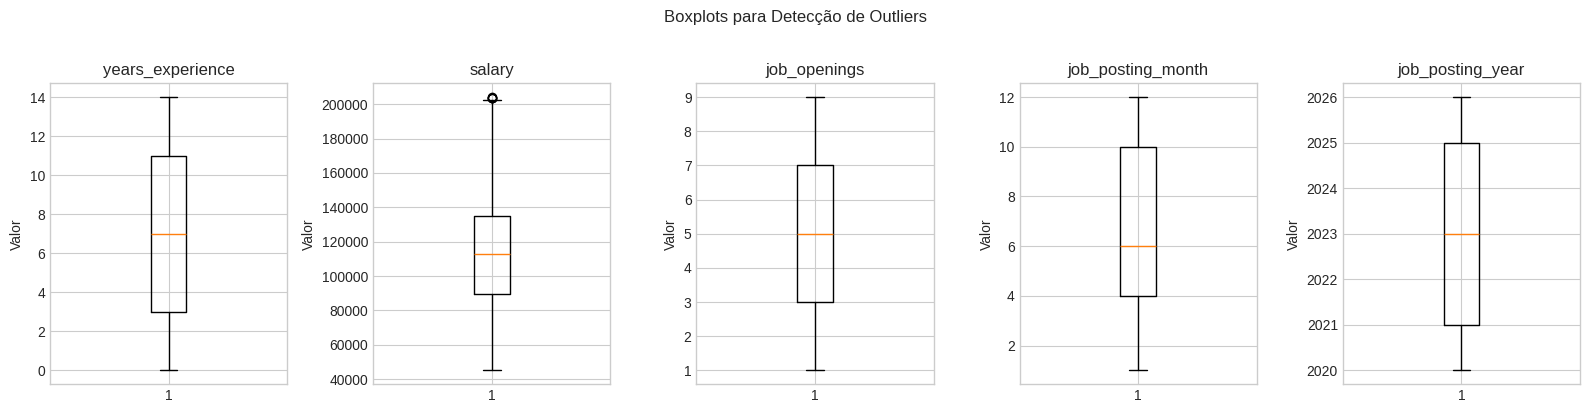


✓ Nota: Neste dataset, os outliers detectados pelo IQR são valores
  dentro de faixas razoáveis e não serão removidos.


In [262]:
# Análise de outliers usando método IQR
def detect_outliers_iqr(data, column):
    """Detecta outliers usando o método IQR (Interquartile Range)."""
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]
    return len(outliers), lower_bound, upper_bound

# Variáveis numéricas para análise de outliers
numeric_for_outliers = ['years_experience', 'salary', 'job_openings', 'job_posting_month', 'job_posting_year']

print("Análise de Outliers (Método IQR):")
print("="*60)

outlier_summary = []
for col in numeric_for_outliers:
    n_outliers, lower, upper = detect_outliers_iqr(df, col)
    pct = (n_outliers / len(df)) * 100
    outlier_summary.append({
        'Variável': col,
        'Outliers': n_outliers,
        '% do Total': f"{pct:.2f}%",
        'Limite Inferior': f"{lower:.2f}",
        'Limite Superior': f"{upper:.2f}"
    })
    
outlier_df = pd.DataFrame(outlier_summary)
print(outlier_df.to_string(index=False))

# Visualização de outliers com boxplots
fig, axes = plt.subplots(1, len(numeric_for_outliers), figsize=(16, 4))
for i, col in enumerate(numeric_for_outliers):
    axes[i].boxplot(df[col])
    axes[i].set_title(f'{col}')
    axes[i].set_ylabel('Valor')

plt.suptitle('Boxplots para Detecção de Outliers', y=1.02)
plt.tight_layout()
plt.savefig('../reports/outliers_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✓ Nota: Neste dataset, os outliers detectados pelo IQR são valores")
print("  dentro de faixas razoáveis e não serão removidos.")

### 3.9 Análise de Multicolinearidade (VIF)

Análise de Multicolinearidade - VIF (Variance Inflation Factor)

Resultados:
            Variável  VIF Interpretação
    years_experience  1.0         Baixa
        job_openings  1.0         Baixa
   job_posting_month  1.0         Baixa
    job_posting_year  1.0         Baixa
       skills_python  1.0         Baixa
          skills_sql  1.0         Baixa
           skills_ml  1.0         Baixa
skills_deep_learning  1.0         Baixa
        skills_cloud  1.0         Baixa


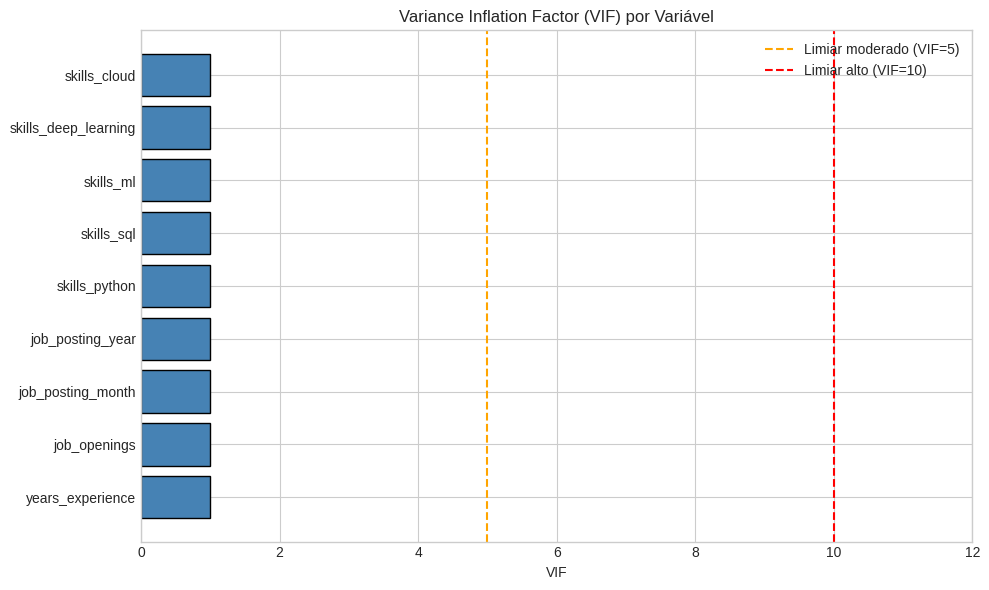


✓ Nenhuma variável apresenta multicolinearidade problemática (VIF < 5).


In [263]:

# Selecionar variáveis numéricas e binárias
numeric_cols_vif = ['years_experience', 'job_openings', 'job_posting_month', 'job_posting_year',
                    'skills_python', 'skills_sql', 'skills_ml', 'skills_deep_learning', 'skills_cloud']

# Criar matriz com a constante indispensável para o cálculo correto no statsmodels
X_vif_with_const = add_constant(df[numeric_cols_vif])

# Calcular VIF para cada variável
vif_data = []
for col in numeric_cols_vif:
    idx = list(X_vif_with_const.columns).index(col)
    vif_value = variance_inflation_factor(X_vif_with_const.values, idx)
    vif_data.append({
        'Variável': col,
        'VIF': round(vif_value, 2),
        'Interpretação': 'Alta' if vif_value > 10 else ('Moderada' if vif_value > 5 else 'Baixa')
    })

vif_df = pd.DataFrame(vif_data).sort_values('VIF', ascending=False)

print("Análise de Multicolinearidade - VIF (Variance Inflation Factor)")
print("="*65)
print("\nResultados:")
print(vif_df.to_string(index=False))

# Visualização
plt.figure(figsize=(10, 6))
colors = ['red' if v > 10 else ('orange' if v > 5 else 'steelblue') for v in vif_df['VIF']]
plt.barh(vif_df['Variável'], vif_df['VIF'], color=colors, edgecolor='black')
plt.axvline(x=5, color='orange', linestyle='--', label='Limiar moderado (VIF=5)')
plt.axvline(x=10, color='red', linestyle='--', label='Limiar alto (VIF=10)')
plt.xlim(0, 12)
plt.xlabel('VIF')
plt.title('Variance Inflation Factor (VIF) por Variável')
plt.legend()
plt.tight_layout()
plt.savefig('../reports/vif_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

# Conclusão
high_vif = vif_df[vif_df['VIF'] > 5]
if len(high_vif) > 0:
    print(f"\n⚠ Variáveis com VIF > 5: {list(high_vif['Variável'])}")
else:
    print("\n✓ Nenhuma variável apresenta multicolinearidade problemática (VIF < 5).")

---
## 4. Pré-processamento

### 4.1 Definição de Variáveis

In [265]:
# Remover job_id (identificador)
df_model = df.drop(columns=['job_id'])

# Definir X
X = df_model.drop(columns=['salary'])

# =============================================================================
# DISCRETIZAÇÃO DO TARGET - LIMITES FIXOS PRÉ-DEFINIDOS
# =============================================================================
# Os limites são definidos ANTES de olhar para qualquer dado.
# Isso evita data leakage: o teste não participa da definição das classes.
# Baseado em conhecimento de domínio sobre faixas salariais típicas.

salary = df_model['salary']

# Limites FIXOS (definidos a priori, não calculados dos dados)
SALARY_BINS = [-np.inf, 70000, 120000, np.inf]
SALARY_LABELS = [0, 1, 2]  # Baixo, Medio, Alto

print("Limites das faixas salariais (PRÉ-DEFINIDOS, não calculados dos dados):")
print(f"  Baixo:  < $70,000")
print(f"  Medio:  $70,000 - $120,000")
print(f"  Alto:   > $120,000")

# Criar target discretizado com limites FIXOS
y = pd.cut(salary, bins=SALARY_BINS, labels=SALARY_LABELS, include_lowest=True).astype(int)

# Verificar distribuição resultante
print(f"\nDistribuição das classes:")
for label, name in enumerate(['Baixo', 'Medio', 'Alto']):
    count = (y == label).sum()
    pct = count / len(y) * 100
    print(f"  {name}: {count} ({pct:.1f}%)")

# Salvar mapeamento e limites
target_mapping = {0: 'Baixo', 1: 'Medio', 2: 'Alto'}
joblib.dump(target_mapping, '../artifacts/target_mapping.pkl')
joblib.dump(SALARY_BINS, '../artifacts/salary_bin_edges.pkl')

print(f"\nFeatures (X): {X.shape}")
print(f"Target (y): {y.shape}")

Limites das faixas salariais (PRÉ-DEFINIDOS, não calculados dos dados):
  Baixo:  < $70,000
  Medio:  $70,000 - $120,000
  Alto:   > $120,000

Distribuição das classes:
  Baixo: 867 (8.4%)
  Medio: 5237 (50.6%)
  Alto: 4241 (41.0%)

Features (X): (10345, 17)
Target (y): (10345,)


In [ ]:
# Classificar as variáveis
# Variáveis numéricas (para padronização)
numeric_features = ['years_experience', 'job_posting_month', 'job_posting_year', 'job_openings']

# Variáveis binárias (já são 0/1)
binary_features = ['skills_python', 'skills_sql', 'skills_ml', 'skills_deep_learning', 'skills_cloud']

# Variáveis ordinais (têm ordem natural)
ordinal_features = ['experience_level', 'education_level', 'hiring_urgency']

# Variáveis nominais (sem ordem - One-Hot)
nominal_features = ['job_title', 'company_size', 'company_industry', 'country', 'remote_type']

print("Variáveis por tipo:")
print(f"  Numéricas: {numeric_features}")
print(f"  Binárias: {binary_features}")
print(f"  Ordinais: {ordinal_features}")
print(f"  Nominais: {nominal_features}")

Variáveis por tipo:
  Numéricas: ['years_experience', 'job_posting_month', 'job_posting_year', 'job_openings', 'total_skills']
  Binárias: ['skills_python', 'skills_sql', 'skills_ml', 'skills_deep_learning', 'skills_cloud']
  Ordinais: ['experience_level', 'education_level', 'hiring_urgency']
  Nominais: ['job_title', 'company_size', 'company_industry', 'country', 'remote_type']


### 4.3 Divisão dos Dados

In [267]:
# SPLIT ESTRATIFICADO: 60% treino, 20% validação, 20% teste


# Primeiro split: 60% treino, 40% temporário (estratificado)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, 
    test_size=0.4, 
    random_state=SEED,
    stratify=y  # Estratificação pelo target
)

# Segundo split: 50% validação, 50% teste do temporário (estratificado)
X_validation, X_test, y_validation, y_test = train_test_split(
    X_temp, y_temp, 
    test_size=0.5, 
    random_state=SEED,
    stratify=y_temp  # Estratificação pelo target
)


### 4.4 Feature Engineering

In [ ]:
# FEATURE ENGINEERING - APÓS O SPLIT

# adiciona total_skills na numeric_features
numeric_features = ['years_experience', 'job_posting_month', 'job_posting_year', 'job_openings', 'total_skills']

# Criar 'total_skills' em cada conjunto separadamente
X_train = X_train.copy()
X_validation = X_validation.copy()
X_test = X_test.copy()

X_train['total_skills'] = X_train[skills_cols].sum(axis=1)
X_validation['total_skills'] = X_validation[skills_cols].sum(axis=1)
X_test['total_skills'] = X_test[skills_cols].sum(axis=1)

print("Atributo derivado 'total_skills' criado APÓS o split.")

print(f"\nDistribuição das classes (estratificada):")
print(f"  Treino:     {np.bincount(y_train)} (n={len(y_train)})")
print(f"  Validação:  {np.bincount(y_validation)} (n={len(y_validation)})")
print(f"  Teste:      {np.bincount(y_test)} (n={len(y_test)})")

print(f"\nProporções:")
print(f"  Treino:    {X_train.shape[0]:,} amostras ({X_train.shape[0]/len(X)*100:.0f}%)")
print(f"  Validação: {X_validation.shape[0]:,} amostras ({X_validation.shape[0]/len(X)*100:.0f}%)")
print(f"  Teste:     {X_test.shape[0]:,} amostras ({X_test.shape[0]/len(X)*100:.0f}%)")
print(f"  Features:  {X_train.shape[1]} (incluindo total_skills)")

Atributo derivado 'total_skills' criado APÓS o split.

Distribuição das classes (estratificada):
  Treino:     [ 520 3142 2545] (n=6207)
  Validação:  [ 174 1047  848] (n=2069)
  Teste:      [ 173 1048  848] (n=2069)

Proporções:
  Treino:    6,207 amostras (60%)
  Validação: 2,069 amostras (20%)
  Teste:     2,069 amostras (20%)
  Features:  18 (incluindo total_skills)


### 4.5 Pipeline de Pré-processamento

In [269]:
# Definir ordens para variáveis ordinais
experience_order = ['Entry', 'Mid', 'Senior']
education_order = ['Bachelor', 'Master', 'PhD']
urgency_order = ['Low', 'Medium', 'High']

def create_preprocessor():
    """Cria um preprocessador NOVO (não ajustado) para uso em Pipelines."""
    return ColumnTransformer(
        transformers=[
            # Numéricas: StandardScaler
            ('num', StandardScaler(), numeric_features),
            
            # Binárias: manter como estão (passthrough)
            ('bin', 'passthrough', binary_features),
            
            # Ordinais: OrdinalEncoder
            ('ord', OrdinalEncoder(categories=[experience_order, education_order, urgency_order]),
                    ordinal_features),
            
            # Nominais: OneHotEncoder
            ('nom', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'),
                    nominal_features)
        ],
        remainder='drop'
    )

# Criar instância para uso direto (será ajustada uma vez para X_train_processed)
preprocessor_fitted = create_preprocessor()

print("Função create_preprocessor() definida!")
print("Use create_preprocessor() em Pipelines para evitar reutilizar objeto já ajustado.")

# Aplicar preprocessamento (usando instância dedicada)
X_train_processed = preprocessor_fitted.fit_transform(X_train)
X_validation_processed = preprocessor_fitted.transform(X_validation)
X_test_processed = preprocessor_fitted.transform(X_test)

print(f"Shape após preprocessamento:")
print(f"  X_train:      {X_train_processed.shape}")
print(f"  X_validation: {X_validation_processed.shape}")
print(f"  X_test:       {X_test_processed.shape}")

Função create_preprocessor() definida!
Use create_preprocessor() em Pipelines para evitar reutilizar objeto já ajustado.
Shape após preprocessamento:
  X_train:      (6207, 34)
  X_validation: (2069, 34)
  X_test:       (2069, 34)


In [270]:
# Salvar preprocessador (já ajustado em X_train)
joblib.dump(preprocessor_fitted, '../artifacts/preprocessor.joblib')
print("Preprocessador salvo em: artifacts/preprocessor.joblib")

Preprocessador salvo em: artifacts/preprocessor.joblib


---
## 5. Modelagem Supervisionada

### 5.1 Função de Avaliação

In [299]:
def evaluate_model(model, X_train, X_val, y_train, y_val, model_name):
    """
    Avalia um modelo de classificação em treino e validação APENAS.
    O conjunto de teste NÃO é usado aqui para evitar data leakage.
    """
    # Previsões
    y_train_pred = model.predict(X_train)
    y_val_pred = model.predict(X_val)
    
    # Métricas de treino
    train_acc = accuracy_score(y_train, y_train_pred)
    train_f1 = f1_score(y_train, y_train_pred, average='macro')
    
    # Métricas de validação
    val_acc = accuracy_score(y_val, y_val_pred)
    val_bal_acc = balanced_accuracy_score(y_val, y_val_pred)
    val_precision = precision_score(y_val, y_val_pred, average='macro', zero_division=0)
    val_recall = recall_score(y_val, y_val_pred, average='macro', zero_division=0)
    val_f1 = f1_score(y_val, y_val_pred, average='macro')
    
    print(f"\n{'='*50}")
    print(f"Modelo: {model_name}")
    print(f"{'='*50}")
    print(f"\nTREINO:")
    print(f"  Acurácia: {train_acc:.4f}")
    print(f"  F1-macro: {train_f1:.4f}")
    print(f"\nVALIDAÇÃO:")
    print(f"  Acurácia:          {val_acc:.4f}")
    print(f"  Acurácia Balanc.:  {val_bal_acc:.4f}")
    print(f"  Precisão (macro):  {val_precision:.4f}")
    print(f"  Revocação (macro): {val_recall:.4f}")
    print(f"  F1-Score (macro):  {val_f1:.4f}")
    
    return {
        'model_name': model_name,
        'train_accuracy': train_acc,
        'train_f1_macro': train_f1,
        'val_accuracy': val_acc,
        'val_balanced_accuracy': val_bal_acc,
        'val_precision': val_precision,
        'val_recall': val_recall,
        'val_f1_macro': val_f1
    }


def evaluate_final_model(model, X_test, y_test, model_name):
    """
    Avaliação FINAL do modelo selecionado no conjunto de TESTE.
    Esta função deve ser chamada APENAS UMA VEZ, após selecionar o melhor modelo.
    """
    y_test_pred = model.predict(X_test)
    
    test_acc = accuracy_score(y_test, y_test_pred)
    test_bal_acc = balanced_accuracy_score(y_test, y_test_pred)
    test_precision = precision_score(y_test, y_test_pred, average='macro', zero_division=0)
    test_recall = recall_score(y_test, y_test_pred, average='macro', zero_division=0)
    test_f1 = f1_score(y_test, y_test_pred, average='macro')
    
    print(f"\n{'='*60}")
    print(f"AVALIAÇÃO FINAL NO CONJUNTO DE TESTE")
    print(f"Modelo: {model_name}")
    print(f"{'='*60}")
    print(f"  Acurácia:          {test_acc:.4f}")
    print(f"  Acurácia Balanc.:  {test_bal_acc:.4f}")
    print(f"  Precisão (macro):  {test_precision:.4f}")
    print(f"  Revocação (macro): {test_recall:.4f}")
    print(f"  F1-Score (macro):  {test_f1:.4f}")
    
    return {
        'model_name': model_name,
        'test_accuracy': test_acc,
        'test_balanced_accuracy': test_bal_acc,
        'test_precision': test_precision,
        'test_recall': test_recall,
        'test_f1_macro': test_f1,
        'y_pred': y_test_pred
    }

### 5.2 Compração: Baseline (Classe Majoritária)

In [272]:
    baseline_model = DummyClassifier(strategy="most_frequent", random_state=SEED)
    baseline_model.fit(X_train_processed, y_train)

    baseline_results = evaluate_model(
        baseline_model, 
        X_train_processed, X_validation_processed,
        y_train, y_validation, 
        'Baseline (Majoritária)'
    )


Modelo: Baseline (Majoritária)

TREINO:
  Acurácia: 0.5062
  F1-macro: 0.2241

VALIDAÇÃO:
  Acurácia:          0.5060
  Acurácia Balanc.:  0.3333
  Precisão (macro):  0.1687
  Revocação (macro): 0.3333
  F1-Score (macro):  0.2240


### 5.3 Modelo 1: Modelo Linear (Logistic Regression)

In [300]:
# Treinar modelo
lr_model = LogisticRegression(random_state=SEED, max_iter=1000)
lr_model.fit(X_train_processed, y_train)

lr_results = evaluate_model(
    lr_model, 
    X_train_processed, X_validation_processed,
    y_train, y_validation, 
    'Logistic Regression'
)


Modelo: Logistic Regression

TREINO:
  Acurácia: 0.9766
  F1-macro: 0.9715

VALIDAÇÃO:
  Acurácia:          0.9749
  Acurácia Balanc.:  0.9791
  Precisão (macro):  0.9587
  Revocação (macro): 0.9791
  F1-Score (macro):  0.9684


### 5.4 Modelo 2: Random Forest

In [274]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=SEED,
    n_jobs=-1
)
rf_model.fit(X_train_processed, y_train)

rf_results = evaluate_model(
    rf_model, 
    X_train_processed, X_validation_processed,
    y_train, y_validation, 
    'Random Forest'
)


Modelo: Random Forest

TREINO:
  Acurácia: 0.9578
  F1-macro: 0.9495

VALIDAÇÃO:
  Acurácia:          0.8840
  Acurácia Balanc.:  0.7595
  Precisão (macro):  0.9322
  Revocação (macro): 0.7595
  F1-Score (macro):  0.8064


### 5.5 Modelo 3: SVM (Support Vector Machine)

Família: **Baseado em margens** - diferente de modelos lineares e ensembles de árvores.

In [275]:
from sklearn.svm import SVC

# Treinar modelo SVM com kernel RBF
svm_model = SVC(
    kernel='rbf',
    C=1.0,
    gamma='scale',
    random_state=SEED,
    probability=True  # Necessário para predict_proba (ROC curve)
)
svm_model.fit(X_train_processed, y_train)

# Avaliar
svm_results = evaluate_model(
    svm_model, 
    X_train_processed, X_validation_processed,
    y_train, y_validation, 
    'SVM (RBF)'
)


Modelo: SVM (RBF)

TREINO:
  Acurácia: 0.9731
  F1-macro: 0.9740

VALIDAÇÃO:
  Acurácia:          0.9536
  Acurácia Balanc.:  0.9493
  Precisão (macro):  0.9537
  Revocação (macro): 0.9493
  F1-Score (macro):  0.9513


### 5.6 Modelo 5: XGBoost (Experimento Adicional)

Nota: XGBoost é um ensemble baseado em árvores (mesma família do Random Forest). Incluído como experimento adicional, não para atender o requisito de famílias distintas.

In [276]:
# # Treinar modelo
# xgb_model = XGBClassifier(
#     n_estimators=100,
#     max_depth=6,
#     learning_rate=0.1,
#     random_state=SEED,
#     n_jobs=-1,
#     use_label_encoder=False,
#     eval_metric='mlogloss'
# )
# xgb_model.fit(X_train_processed, y_train)

# # Avaliar
# xgb_results = evaluate_model(
#     xgb_model, 
#     X_train_processed, X_validation_processed,
#     y_train, y_validation, 
#     'XGBoost'
# )

In [277]:
print("lr_results:", lr_results)
print("rf_results:", rf_results)
print("svm_results:", svm_results)
# print("xgb_results:", xgb_results)

lr_results: {'model_name': 'Logistic Regression', 'train_accuracy': 0.9766392782342517, 'train_f1_macro': np.float64(0.9715312156745299), 'val_accuracy': 0.9748670855485742, 'val_balanced_accuracy': np.float64(0.9791294078546858), 'val_precision': np.float64(0.9586907511552646), 'val_recall': np.float64(0.9791294078546858), 'val_f1_macro': np.float64(0.9684093578456942)}
rf_results: {'model_name': 'Random Forest', 'train_accuracy': 0.9577895923956823, 'train_f1_macro': np.float64(0.9495394833943006), 'val_accuracy': 0.8840019333011117, 'val_balanced_accuracy': np.float64(0.7594597896894122), 'val_precision': np.float64(0.9322436487390767), 'val_recall': np.float64(0.7594597896894122), 'val_f1_macro': np.float64(0.8063857777051657)}
svm_results: {'model_name': 'SVM (RBF)', 'train_accuracy': 0.9730948928628967, 'train_f1_macro': np.float64(0.9740064252333563), 'val_accuracy': 0.9536007733204447, 'val_balanced_accuracy': np.float64(0.9492792348847292), 'val_precision': np.float64(0.953734

### 5.7 Comparação dos Modelos (Treino e Validação)

**Importante:** A seleção do melhor modelo é feita com base no conjunto de **validação**.  
O conjunto de **teste** será usado apenas UMA vez, ao final, para avaliação do modelo selecionado.

In [278]:
# Criar DataFrame com resultados (apenas treino e validação - split único)
# NOTA: Esta comparação é EXPLORATÓRIA. A seleção final do modelo será via CV (célula 59).
results_df = pd.DataFrame([baseline_results, lr_results, rf_results, svm_results])
results_df = results_df.set_index('model_name')

print("\nComparação dos Modelos (Split Único - apenas exploratória):")
print(results_df.round(3))

# Dicionário para mapear nome do modelo ao objeto do modelo
models_dict = {
    'Baseline (Majority)': baseline_model,
    'Logistic Regression': lr_model,
    'Random Forest': rf_model,
    'SVM (RBF)': svm_model,
    # 'XGBoost': xgb_model
}

# Nota: A seleção definitiva será feita via CV na célula 59
print("\n⚠️ NOTA: A seleção final do melhor modelo será baseada em validação cruzada (próxima seção).")


Comparação dos Modelos (Split Único - apenas exploratória):
                        train_accuracy  train_f1_macro  val_accuracy  \
model_name                                                             
Baseline (Majoritária)           0.506           0.224         0.506   
Logistic Regression              0.977           0.972         0.975   
Random Forest                    0.958           0.950         0.884   
SVM (RBF)                        0.973           0.974         0.954   

                        val_balanced_accuracy  val_precision  val_recall  \
model_name                                                                 
Baseline (Majoritária)                  0.333          0.169       0.333   
Logistic Regression                     0.979          0.959       0.979   
Random Forest                           0.759          0.932       0.759   
SVM (RBF)                               0.949          0.954       0.949   

                        val_f1_macro  
model_name

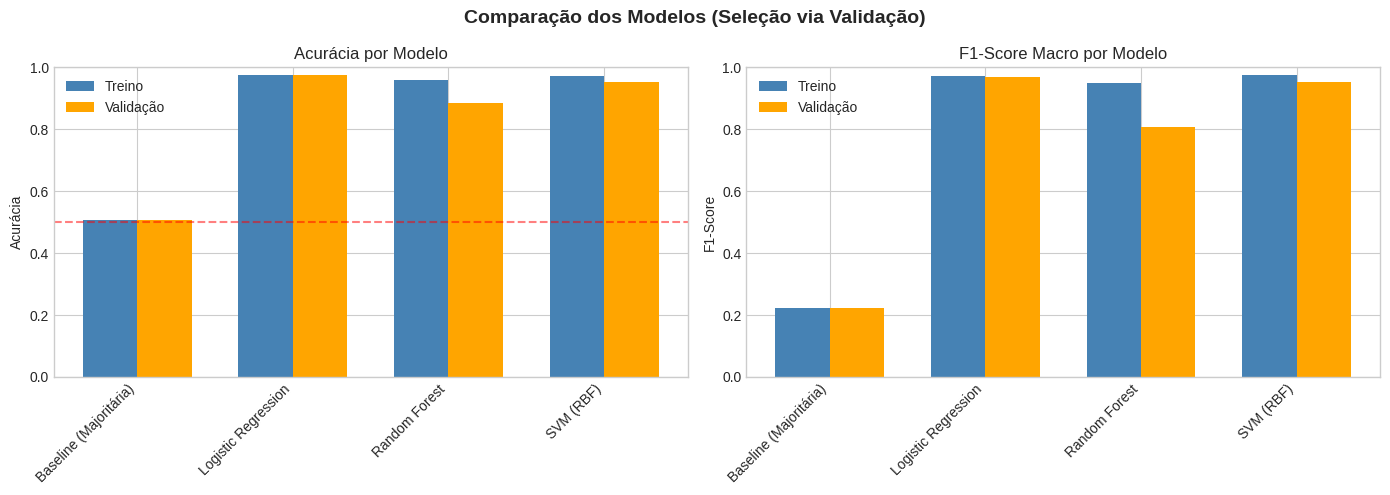


⚠️ Próximo passo: Avaliar o melhor modelo no conjunto de TESTE (apenas uma vez)


In [279]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

models = results_df.index.tolist()
x = np.arange(len(models))
width = 0.35

# Acurácia (apenas treino e validação)
axes[0].bar(x - width/2, results_df['train_accuracy'], width, label='Treino', color='steelblue')
axes[0].bar(x + width/2, results_df['val_accuracy'], width, label='Validação', color='orange')
axes[0].set_title('Acurácia por Modelo')
axes[0].set_ylabel('Acurácia')
axes[0].set_xticks(x)
axes[0].set_xticklabels(models, rotation=45, ha='right')
axes[0].set_ylim(0, 1)
axes[0].legend()
axes[0].axhline(y=0.5, color='r', linestyle='--', alpha=0.5, label='Baseline 50%')

# F1-Score Macro (apenas treino e validação)
axes[1].bar(x - width/2, results_df['train_f1_macro'], width, label='Treino', color='steelblue')
axes[1].bar(x + width/2, results_df['val_f1_macro'], width, label='Validação', color='orange')
axes[1].set_title('F1-Score Macro por Modelo')
axes[1].set_ylabel('F1-Score')
axes[1].set_xticks(x)
axes[1].set_xticklabels(models, rotation=45, ha='right')
axes[1].set_ylim(0, 1)
axes[1].legend()

plt.suptitle('Comparação dos Modelos (Seleção via Validação)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/model_comparison_validation.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n⚠️ Próximo passo: Avaliar o melhor modelo no conjunto de TESTE (apenas uma vez)")

### 5.8 Validação cruzada com média e desvio-padrão (Conjunto de Treino)

In [280]:
# =============================================================================
# VALIDAÇÃO CRUZADA CORRETA (preprocessador dentro do CV)
# =============================================================================
# O preprocessador deve ser re-ajustado em cada fold para evitar data leakage.
# Por isso, usamos Pipeline que inclui o preprocessador + modelo.
# IMPORTANTE: Cada pipeline usa create_preprocessor() para ter instância NOVA.

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

# Criar Pipelines com preprocessador NOVO + modelo
pipelines = {
    'Baseline (Majoritária)': Pipeline([
        ('preprocessor', create_preprocessor()),
        ('classifier', DummyClassifier(strategy='most_frequent', random_state=SEED))
    ]),
    'Logistic Regression': Pipeline([
        ('preprocessor', create_preprocessor()),
        ('classifier', LogisticRegression(random_state=SEED, max_iter=1000))
    ]),
    'Random Forest': Pipeline([
        ('preprocessor', create_preprocessor()),
        ('classifier', RandomForestClassifier(n_estimators=100, max_depth=10, random_state=SEED, n_jobs=-1))
    ]),
    'SVM (RBF)': Pipeline([
        ('preprocessor', create_preprocessor()),
        ('classifier', SVC(kernel='rbf', C=1.0, gamma='scale', random_state=SEED, probability=True))
    ])
    # 'XGBoost': Pipeline([
    #     ('preprocessor', create_preprocessor()),
    #     ('classifier', XGBClassifier(n_estimators=100, max_depth=6, learning_rate=0.1,
    #                                  random_state=SEED, n_jobs=-1, eval_metric='mlogloss'))
    # ])
}

cv_results = []
print("Validação Cruzada Estratificada (5-fold) - F1-macro:")
print("="*55)

for name, pipeline in pipelines.items():
    # Usar X_train (NÃO processado) para que o Pipeline faça o fit em cada fold
    scores = cross_val_score(pipeline, X_train, y_train, cv=skf, scoring='f1_macro')
    media = np.mean(scores)
    desvio = np.std(scores)
    print(f"{name:25s}: {media:.4f} (+/- {desvio:.4f})")
    cv_results.append({'Modelo': name, 'F1_mean': media, 'F1_std': desvio})

cv_df = pd.DataFrame(cv_results)
print("\n", cv_df)

# =============================================================================
# SELEÇÃO DO MELHOR MODELO BASEADA EM CV (não split único)
# =============================================================================
best_cv_model_name = cv_df.loc[cv_df['F1_mean'].idxmax(), 'Modelo']
best_cv_model_pipeline = pipelines[best_cv_model_name]

# Treinar o pipeline no conjunto de treino completo
best_cv_model_pipeline.fit(X_train, y_train)

print(f"\n✓ Melhor modelo (via CV): {best_cv_model_name}")
print(f"  F1-macro CV: {cv_df.loc[cv_df['Modelo'] == best_cv_model_name, 'F1_mean'].values[0]:.4f}")

Validação Cruzada Estratificada (5-fold) - F1-macro:
Baseline (Majoritária)   : 0.2241 (+/- 0.0001)
Logistic Regression      : 0.9683 (+/- 0.0053)
Random Forest            : 0.8141 (+/- 0.0166)
SVM (RBF)                : 0.9509 (+/- 0.0077)

                    Modelo   F1_mean    F1_std
0  Baseline (Majoritária)  0.224052  0.000057
1     Logistic Regression  0.968273  0.005301
2           Random Forest  0.814062  0.016622
3               SVM (RBF)  0.950884  0.007705

✓ Melhor modelo (via CV): Logistic Regression
  F1-macro CV: 0.9683


### 5.9 Matriz de Confusão no Conjunto de Validação

**Nota:** Durante a seleção de modelos, usamos o conjunto de validação.  
A matriz de confusão no conjunto de TESTE será gerada apenas após a seleção final.

Avaliando: Logistic Regression


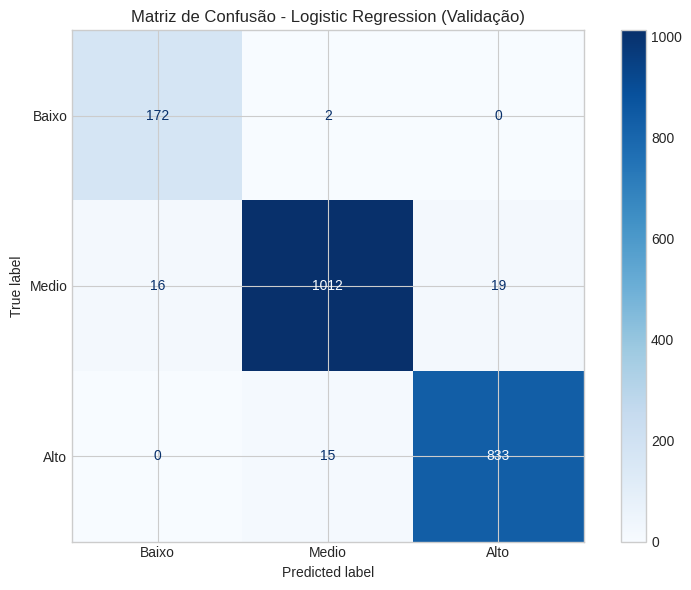


Matriz de Confusão (Validação):
       Baixo  Medio  Alto
Baixo    172      2     0
Medio     16   1012    19
Alto       0     15   833


In [281]:
# Usar o melhor modelo selecionado via CV (definido na célula 59)
print(f"Avaliando: {best_cv_model_name}")

# Previsões no conjunto de VALIDAÇÃO (não teste!)
# O pipeline inclui o preprocessador, então usamos X_validation (raw)
y_val_pred = best_cv_model_pipeline.predict(X_validation)

# Matriz de confusão
cm_val = confusion_matrix(y_validation, y_val_pred)

# Nomes das classes (do target_mapping: {0: 'Baixo', 1: 'Medio', 2: 'Alto'})
class_names = [target_mapping[i] for i in range(len(target_mapping))]

# Visualização
fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_val, display_labels=class_names)
disp.plot(ax=ax, cmap='Blues', values_format='d')
plt.title(f'Matriz de Confusão - {best_cv_model_name} (Validação)')
plt.tight_layout()
plt.savefig('../reports/confusion_matrix_validation.png', dpi=150, bbox_inches='tight')
plt.show()

# Exibir valores
print("\nMatriz de Confusão (Validação):")
print(pd.DataFrame(cm_val, index=class_names, columns=class_names))

### 5.10 Curva ROC One-vs-Rest (Validação)

**Nota:** Esta análise usa o conjunto de validação para seleção de modelo.

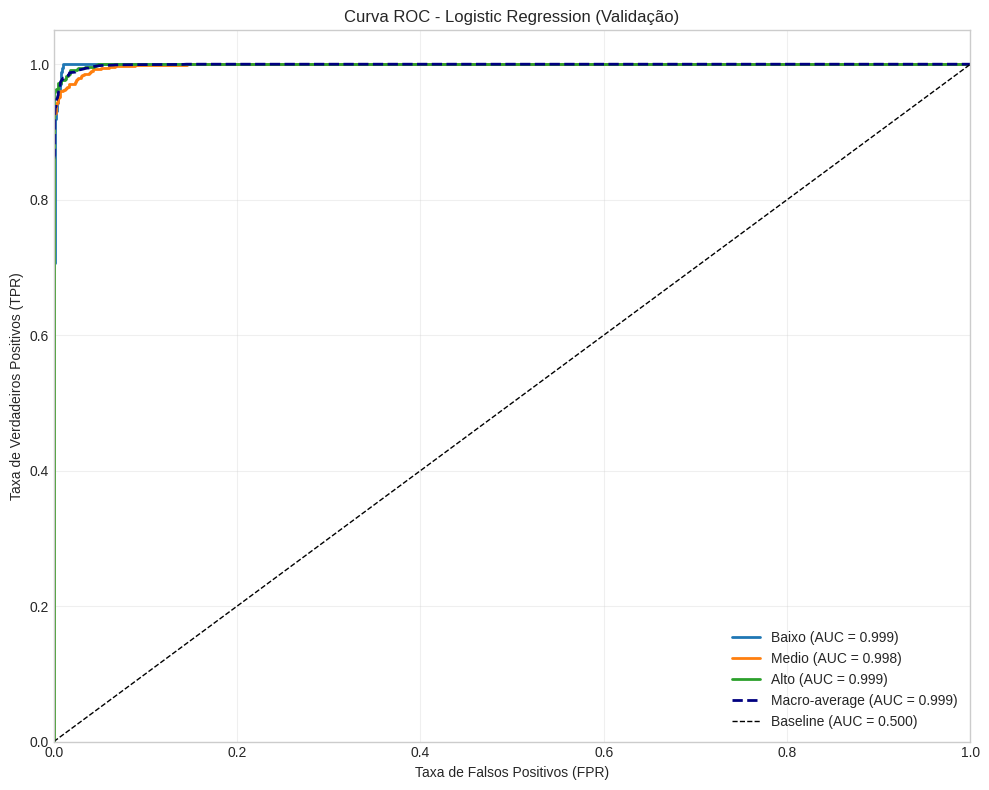


AUC por classe (Validação) - Logistic Regression:
  Baixo: 0.9993
  Medio: 0.9984
  Alto: 0.9994

AUC Macro: 0.9991


In [282]:
# Binarizar y_validation para OvR (3 classes)
n_classes = len(target_mapping)
y_val_bin = label_binarize(y_validation, classes=[0, 1, 2])

# Obter probabilidades do melhor modelo (selecionado via CV na célula 59)
# O pipeline inclui o preprocessador, então usamos X_validation (raw)
y_score_val = best_cv_model_pipeline.predict_proba(X_validation)

# Calcular ROC para cada classe
fpr = {}
tpr = {}
roc_auc = {}

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_val_bin[:, i], y_score_val[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Calcular ROC macro (média)
all_fpr = np.unique(np.concatenate([fpr[i] for i in range(n_classes)]))
mean_tpr = np.zeros_like(all_fpr)
for i in range(n_classes):
    mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])
mean_tpr /= n_classes
roc_auc_macro = auc(all_fpr, mean_tpr)

# Plot
plt.figure(figsize=(10, 8))

# Curva de cada classe
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']
class_names = [target_mapping[i] for i in range(n_classes)]

for i, color in enumerate(colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label=f'{class_names[i]} (AUC = {roc_auc[i]:.3f})')

# Curva macro média
plt.plot(all_fpr, mean_tpr, color='navy', lw=2, linestyle='--',
         label=f'Macro-average (AUC = {roc_auc_macro:.3f})')

# Linha diagonal (baseline)
plt.plot([0, 1], [0, 1], 'k--', lw=1, label='Baseline (AUC = 0.500)')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Taxa de Falsos Positivos (FPR)')
plt.ylabel('Taxa de Verdadeiros Positivos (TPR)')
plt.title(f'Curva ROC - {best_cv_model_name} (Validação)')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../reports/roc_curve_ovr_validation.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nAUC por classe (Validação) - {best_cv_model_name}:")
for i, name in enumerate(class_names):
    print(f"  {name}: {roc_auc[i]:.4f}")
print(f"\nAUC Macro: {roc_auc_macro:.4f}")

---
## 6. Otimização de Hiperparâmetros

### 6.1 GridSeachCV no Random Forest

In [ ]:
# ===========================================================================
# GridSearchCV com Pipeline (evita data leakage)
# ===========================================================================
# O preprocessador é incluído no Pipeline para ser re-ajustado em cada fold

# Grid REDUZIDO para ≤10 combinações (máximo 50 fits com 5 folds)
# Conforme limite explícito do enunciado: "teto de 50 avaliações"
param_grid = {
    'classifier__n_estimators': [100, 200],        # 2 valores
    'classifier__max_depth': [10, 20],             # 2 valores
    'classifier__max_features': [0.5, 1.0]         # 2 valores
}
# Total: 2 × 2 × 2 = 8 combinações × 5 folds = 40 fits (< 50)
 
# Pipeline com preprocessador NOVO + modelo
pipeline_rf = Pipeline([
    ('preprocessor', create_preprocessor()),
    ('classifier', RandomForestClassifier(random_state=SEED, n_jobs=-1))
])

n_combinations = 2 * 2 * 2
n_fits = n_combinations * 5
print("="*60)
print("ESTRATÉGIA 1: Grid Search")
print("="*60)
print(f"Total de combinações: {n_combinations}")
print(f"Total de fits (com 5-fold CV): {n_fits} (≤50 conforme enunciado)")

grid_start = time.time()

grid_search = GridSearchCV(
    estimator=pipeline_rf,
    param_grid=param_grid,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED),
    scoring='f1_macro',
    verbose=1,
    n_jobs=-1
)

# Usar X_train RAW (não processado) - Pipeline faz preprocessing em cada fold
grid_search.fit(X_train, y_train)

grid_time = time.time() - grid_start

print(f"\n✓ GridSearchCV concluído em {grid_time:.2f} segundos!")

ESTRATÉGIA 1: Grid Search
Total de combinações: 8
Total de fits (com 5-fold CV): 40 (≤50 conforme enunciado)
Fitting 5 folds for each of 8 candidates, totalling 40 fits



✓ GridSearchCV concluído em 21.06 segundos!


In [284]:
# Melhores parâmetros
print("Melhores hiperparâmetros (GridSearch com Pipeline):")
for param, value in grid_search.best_params_.items():
    print(f"  {param}: {value}")

print(f"\nMelhor F1-macro (CV): {grid_search.best_score_:.4f}")

Melhores hiperparâmetros (GridSearch com Pipeline):
  classifier__max_depth: 20
  classifier__max_features: 0.5
  classifier__n_estimators: 200

Melhor F1-macro (CV): 0.9703


In [285]:
# Avaliar modelo otimizado
# O best_estimator_ é um Pipeline completo (preprocessor + classifier)
# Deve receber dados RAW, não preprocessados!
best_rf_pipeline = grid_search.best_estimator_

# Avaliar pipeline completo com dados RAW (apenas treino/validação)
best_rf_results = evaluate_model(
    best_rf_pipeline, 
    X_train,           # Dados RAW, não X_train_processed!
    X_validation,      # Dados RAW, não X_validation_processed!
    y_train, 
    y_validation,
    'Random Forest (Otimizado via GridSearch)'
)

# Extrair apenas o classifier para uso posterior (com dados já preprocessados)
best_rf_model = best_rf_pipeline.named_steps['classifier']


Modelo: Random Forest (Otimizado via GridSearch)

TREINO:
  Acurácia: 1.0000
  F1-macro: 1.0000

VALIDAÇÃO:
  Acurácia:          0.9720
  Acurácia Balanc.:  0.9635
  Precisão (macro):  0.9753
  Revocação (macro): 0.9635
  F1-Score (macro):  0.9692


In [286]:
# Salvar melhor modelo
joblib.dump(best_rf_model, '../models/best_random_forest.joblib')
print("Modelo salvo em: models/best_random_forest.joblib")

Modelo salvo em: models/best_random_forest.joblib


### 6.2 Features Importantes

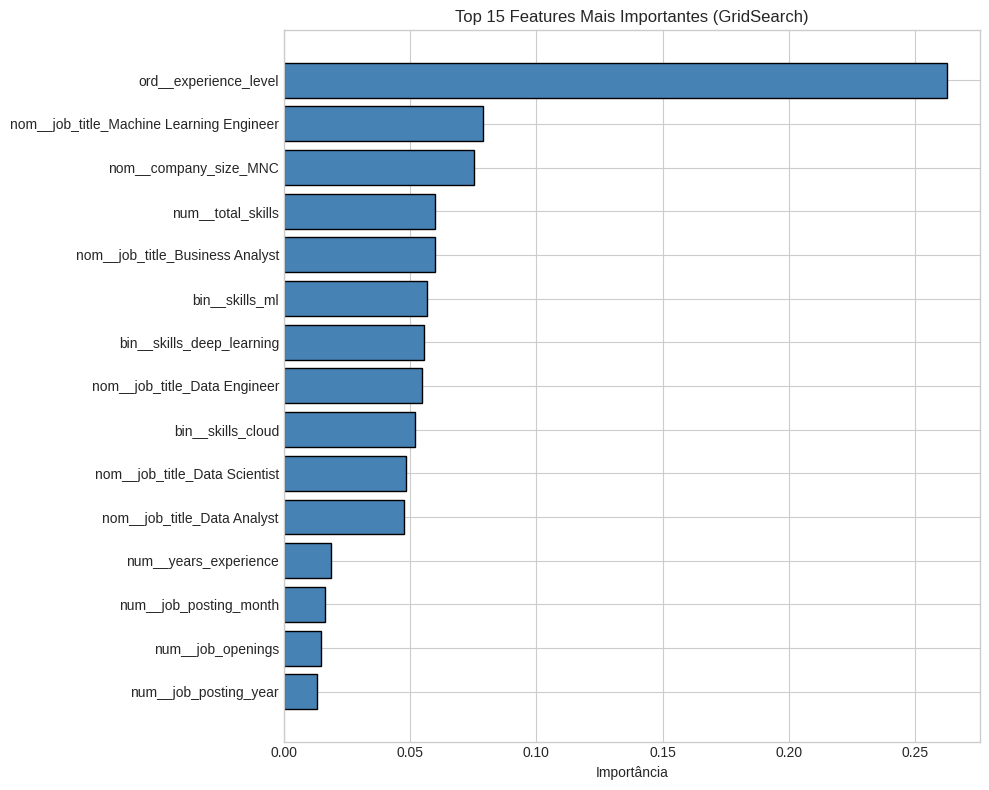

In [287]:
# Obter nomes das features usando o preprocessor DO PIPELINE (consistência)
pipeline_preprocessor = best_rf_pipeline.named_steps['preprocessor']
feature_names = pipeline_preprocessor.get_feature_names_out()

# Feature importance (best_rf_model é o classifier extraído do pipeline)
importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': best_rf_model.feature_importances_
}).sort_values('importance', ascending=False)

# Top 15 features
plt.figure(figsize=(10, 8))
top_features = importance_df.head(15)
plt.barh(top_features['feature'], top_features['importance'], color='steelblue', edgecolor='black')
plt.xlabel('Importância')
plt.title('Top 15 Features Mais Importantes (GridSearch)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('../reports/feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

### 6.2 Otimização Bayesiana (Optuna)

In [288]:
def objective(trial):
    """Função objetivo para Optuna - com Pipeline para evitar data leakage."""
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 200),
        'max_depth': trial.suggest_int('max_depth', 3, 20),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 15),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 10),
        'max_features': trial.suggest_float('max_features', 0.1, 1.0),
        'random_state': SEED,
        'n_jobs': -1
    }
    
    # Pipeline com preprocessador NOVO + modelo (evita data leakage)
    pipeline = Pipeline([
        ('preprocessor', create_preprocessor()),
        ('classifier', RandomForestClassifier(**params))
    ])
    
    # Validação cruzada estratificada usando X_train RAW
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
    scores = cross_val_score(pipeline, X_train, y_train, cv=skf, scoring='f1_macro')
    
    return scores.mean()

print("="*60)
print("ESTRATÉGIA 2: Otimização Bayesiana (Optuna)")
print("="*60)
print("Espaço de busca:")
print("  n_estimators: [50, 200] (inteiro)")
print("  max_depth: [3, 20] (inteiro)")
print("  min_samples_split: [2, 15] (inteiro)")
print("  min_samples_leaf: [1, 10] (inteiro)")
print("  max_features: [0.1, 1.0] (contínuo)")
print(f"\nMáximo de avaliações: 50")

# Medir tempo
start_time_optuna = time.time()

study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=SEED))
study.optimize(objective, n_trials=50, show_progress_bar=False)

optuna_time = time.time() - start_time_optuna

print(f"\n✓ Optuna concluído em {optuna_time:.2f} segundos")
print(f"\nMelhores hiperparâmetros:")
for param, value in study.best_params.items():
    print(f"  {param}: {value}")
print(f"\nMelhor F1-macro (CV): {study.best_value:.4f}")

ESTRATÉGIA 2: Otimização Bayesiana (Optuna)
Espaço de busca:
  n_estimators: [50, 200] (inteiro)
  max_depth: [3, 20] (inteiro)
  min_samples_split: [2, 15] (inteiro)
  min_samples_leaf: [1, 10] (inteiro)
  max_features: [0.1, 1.0] (contínuo)

Máximo de avaliações: 50

✓ Optuna concluído em 179.08 segundos

Melhores hiperparâmetros:
  n_estimators: 65
  max_depth: 16
  min_samples_split: 6
  min_samples_leaf: 1
  max_features: 0.4046840493837703

Melhor F1-macro (CV): 0.9714


### 6.3 Comparação das Estratégias de Otimização

COMPARAÇÃO DAS ESTRATÉGIAS DE OTIMIZAÇÃO
         Estratégia  Melhor F1-macro Tempo (s)  Nº Ajustes Ganho vs Padrão
Configuração Padrão         0.910822         -           1               -
        Grid Search         0.970307     21.06          40          +5.95%
 Optuna (Bayesiana)         0.971384    179.08         250          +6.06%


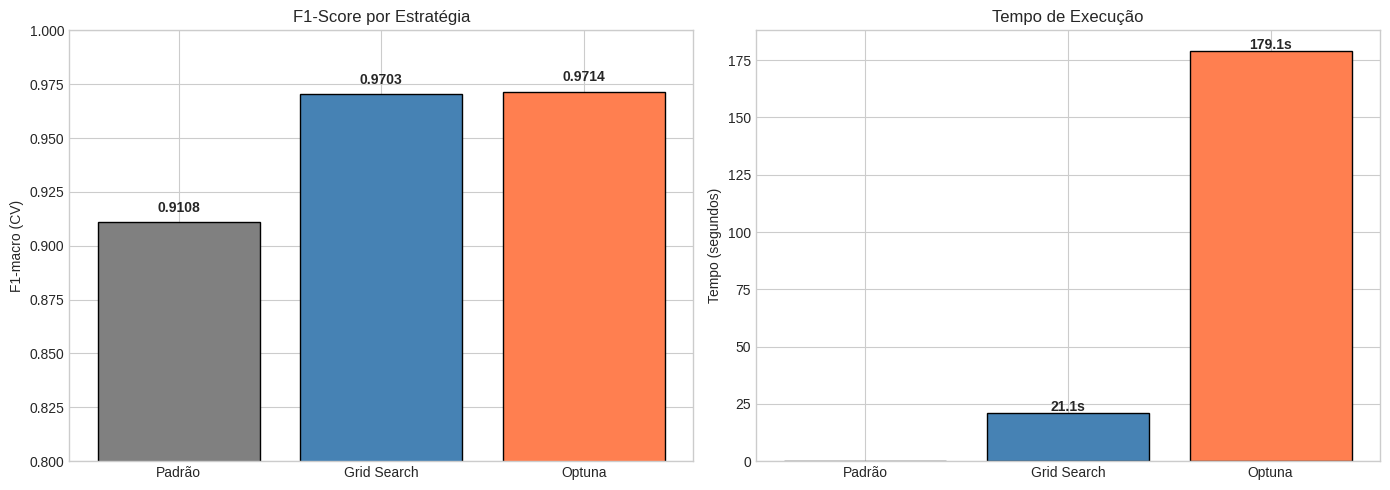

In [289]:
# Pipeline para modelo padrão (evita data leakage)
pipeline_default = Pipeline([
    ('preprocessor', create_preprocessor()),
    ('classifier', RandomForestClassifier(random_state=SEED, n_jobs=-1))
])

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
default_scores = cross_val_score(pipeline_default, X_train, y_train, cv=skf, scoring='f1_macro')
default_f1 = default_scores.mean()

# Calcular número de ajustes dinamicamente
n_grid_combinations = len(grid_search.cv_results_['params'])
n_grid_folds = grid_search.n_splits_
n_grid_fits = n_grid_combinations * n_grid_folds

n_optuna_trials = len(study.trials)
n_optuna_fits = n_optuna_trials * 5  # 5 folds

# Resultados
comparison = pd.DataFrame({
    'Estratégia': ['Configuração Padrão', 'Grid Search', 'Optuna (Bayesiana)'],
    'Melhor F1-macro': [default_f1, grid_search.best_score_, study.best_value],
    'Tempo (s)': ['-', f'{grid_time:.2f}', f'{optuna_time:.2f}'],
    'Nº Ajustes': [1, n_grid_fits, n_optuna_fits],
    'Ganho vs Padrão': [
        '-',
        f'+{(grid_search.best_score_ - default_f1)*100:.2f}%',
        f'+{(study.best_value - default_f1)*100:.2f}%'
    ]
})

print("="*60)
print("COMPARAÇÃO DAS ESTRATÉGIAS DE OTIMIZAÇÃO")
print("="*60)
print(comparison.to_string(index=False))

# Visualização
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# F1-Score
strategies = ['Padrão', 'Grid Search', 'Optuna']
f1_scores = [default_f1, grid_search.best_score_, study.best_value]
colors = ['gray', 'steelblue', 'coral']

axes[0].bar(strategies, f1_scores, color=colors, edgecolor='black')
axes[0].set_ylabel('F1-macro (CV)')
axes[0].set_title('F1-Score por Estratégia')
axes[0].set_ylim(0.8, 1.0)
for i, v in enumerate(f1_scores):
    axes[0].text(i, v + 0.005, f'{v:.4f}', ha='center', fontweight='bold')

# Tempo
times = [0, grid_time, optuna_time]
axes[1].bar(strategies, times, color=colors, edgecolor='black')
axes[1].set_ylabel('Tempo (segundos)')
axes[1].set_title('Tempo de Execução')
for i, v in enumerate(times):
    if v > 0:
        axes[1].text(i, v + 1, f'{v:.1f}s', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('../reports/optimization_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

### 6.4 Modelo Final Otimizado

In [290]:
# Usar melhores parâmetros (Optuna ou Grid, escolher o melhor)
# Nota: GridSearch usa prefixo 'classifier__', precisamos remover para usar no modelo

# Extrair parâmetros do GridSearch (removendo prefixo 'classifier__')
grid_params_clean = {k.replace('classifier__', ''): v for k, v in grid_search.best_params_.items()}

# Determinar melhor estratégia dinamicamente
if study.best_value >= grid_search.best_score_:
    best_strategy = 'Optuna'
    best_params = study.best_params
    best_cv_score = study.best_value
    print(f"Usando parâmetros do Optuna (F1-macro CV: {study.best_value:.4f})")
else:
    best_strategy = 'Grid Search'
    best_params = grid_params_clean
    best_cv_score = grid_search.best_score_
    print(f"Usando parâmetros do Grid Search (F1-macro CV: {grid_search.best_score_:.4f})")

# Pipeline com preprocessador + modelo otimizado
best_rf_pipeline = Pipeline([
    ('preprocessor', create_preprocessor()),
    ('classifier', RandomForestClassifier(**best_params, random_state=SEED, n_jobs=-1))
])

# Treinar no conjunto de treino completo (X_train RAW)
best_rf_pipeline.fit(X_train, y_train)

# Avaliar no conjunto de validação (NÃO no teste ainda!)
y_val_pred_rf = best_rf_pipeline.predict(X_validation)

print(f"\n{'='*50}")
print(f"Random Forest Otimizado ({best_strategy}) - Validação")
print(f"{'='*50}")
print(f"Acurácia:         {accuracy_score(y_validation, y_val_pred_rf):.4f}")
print(f"Acurácia Balanc.: {balanced_accuracy_score(y_validation, y_val_pred_rf):.4f}")
print(f"Precisão Macro:   {precision_score(y_validation, y_val_pred_rf, average='macro'):.4f}")
print(f"Recall Macro:     {recall_score(y_validation, y_val_pred_rf, average='macro'):.4f}")
print(f"F1-Macro:         {f1_score(y_validation, y_val_pred_rf, average='macro'):.4f}")

# Salvar pipeline
joblib.dump(best_rf_pipeline, '../models/best_rf_pipeline.joblib')
print(f"\n✓ Pipeline salvo em: models/best_rf_pipeline.joblib")

Usando parâmetros do Optuna (F1-macro CV: 0.9714)

Random Forest Otimizado (Optuna) - Validação
Acurácia:         0.9705
Acurácia Balanc.: 0.9594
Precisão Macro:   0.9726
Recall Macro:     0.9594
F1-Macro:         0.9658

✓ Pipeline salvo em: models/best_rf_pipeline.joblib


---
## 7. Modelagem Não Supervisionada

### 7.1 K-Means - Exploração

Análise exploratória de clusters (apenas para visualização)...


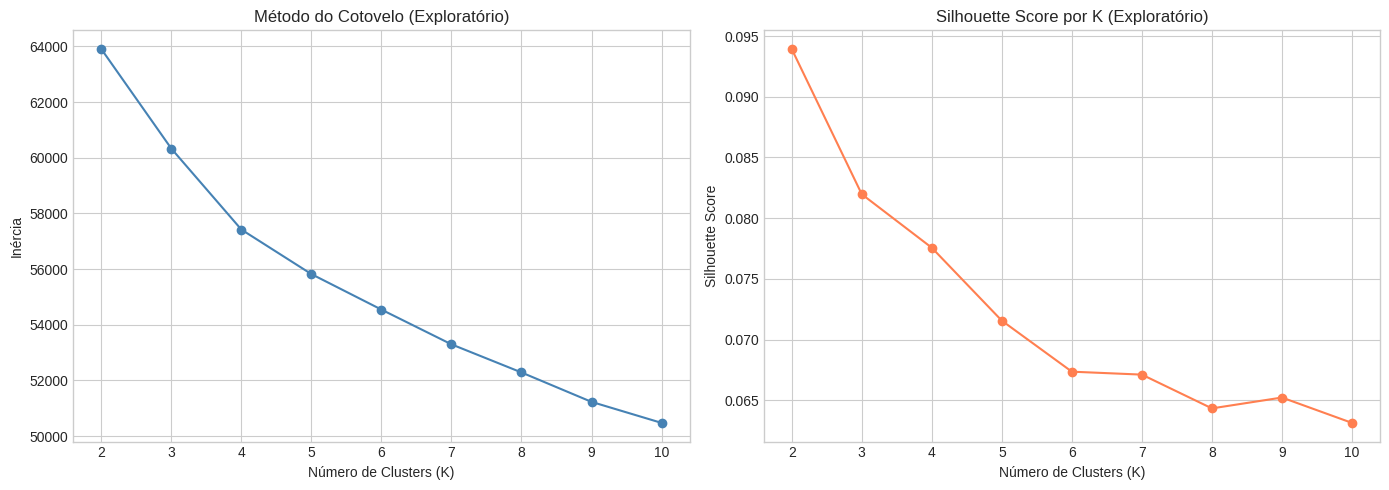


K sugerido pela análise exploratória: 2
⚠️ NOTA: Este K é apenas referência. A seleção final será feita dentro de cada fold.


In [291]:
# Transformer customizado para adicionar cluster como feature
class ClusterFeatureAdder(BaseEstimator, TransformerMixin):
    def __init__(self, n_clusters=4, random_state=67):
        self.n_clusters = n_clusters
        self.random_state = random_state
        self.kmeans = None
    
    def fit(self, X, y=None):
        self.kmeans = KMeans(n_clusters=self.n_clusters, random_state=self.random_state, n_init=10)
        self.kmeans.fit(X)
        return self
    
    def transform(self, X):
        clusters = self.kmeans.predict(X).reshape(-1, 1)
        return np.hstack([X, clusters])

# =============================================================================
# ANÁLISE EXPLORATÓRIA DE CLUSTERS (separada da avaliação de modelo)
# Esta análise serve apenas para visualização e entendimento dos dados.
# A seleção final de K será feita DENTRO de cada fold durante a CV.
# =============================================================================
from sklearn.metrics import silhouette_score

print("Análise exploratória de clusters (apenas para visualização)...")
silhouette_scores_exploratory = []
inertias = []
K_range = range(2, 11)

for k in K_range:
    kmeans_temp = KMeans(n_clusters=k, random_state=SEED, n_init=10)
    labels = kmeans_temp.fit_predict(X_train_processed)
    silhouette_scores_exploratory.append(silhouette_score(X_train_processed, labels))
    inertias.append(kmeans_temp.inertia_)

# Visualização exploratória
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(K_range, inertias, marker='o', color='steelblue')
axes[0].set_xlabel('Número de Clusters (K)')
axes[0].set_ylabel('Inércia')
axes[0].set_title('Método do Cotovelo (Exploratório)')
axes[0].set_xticks(list(K_range))

axes[1].plot(K_range, silhouette_scores_exploratory, marker='o', color='coral')
axes[1].set_xlabel('Número de Clusters (K)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score por K (Exploratório)')
axes[1].set_xticks(list(K_range))

plt.tight_layout()
plt.savefig('../reports/cluster_selection.png', dpi=150, bbox_inches='tight')
plt.show()

best_k_exploratory = K_range[np.argmax(silhouette_scores_exploratory)]
print(f"\nK sugerido pela análise exploratória: {best_k_exploratory}")
print("⚠️ NOTA: Este K é apenas referência. A seleção final será feita dentro de cada fold.")

### 7.2 Comparação: COM vs SEM cluster

In [292]:
# =============================================================================
# COMPARAÇÃO COM vs SEM CLUSTER (metodologia correta)
# K é selecionado DENTRO de cada fold usando silhouette no treino do fold
# =============================================================================

print("Comparando modelos COM vs SEM cluster feature")
print("(K selecionado dentro de cada fold via silhouette score)")

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
K_range = range(2, 8)  # Range de K a testar em cada fold

# =============================================================================
# Modelo SEM cluster feature - usando Pipeline corretamente
# =============================================================================
pipeline_sem_cluster = Pipeline([
    ('preprocessor', create_preprocessor()),
    ('classifier', RandomForestClassifier(**grid_params_clean, random_state=SEED, n_jobs=-1))
])
scores_sem = cross_val_score(pipeline_sem_cluster, X_train, y_train, cv=skf, scoring='f1_macro')

# =============================================================================
# Modelo COM cluster feature - CV manual (K selecionado por fold)
# =============================================================================
scores_com = []
k_per_fold = []

for fold_idx, (train_idx, val_idx) in enumerate(skf.split(X_train, y_train)):
    # Split dos dados RAW
    X_fold_train_raw = X_train.iloc[train_idx]
    X_fold_val_raw = X_train.iloc[val_idx]
    y_fold_train = y_train.iloc[train_idx]
    y_fold_val = y_train.iloc[val_idx]
    
    # Criar preprocessador NOVO para cada fold
    fold_preprocessor = create_preprocessor()
    X_fold_train_proc = fold_preprocessor.fit_transform(X_fold_train_raw)
    X_fold_val_proc = fold_preprocessor.transform(X_fold_val_raw)
    
    # Selecionar K usando silhouette score NO TREINO DO FOLD APENAS
    best_k_fold = 2
    best_silhouette = -1
    for k in K_range:
        kmeans_temp = KMeans(n_clusters=k, random_state=SEED, n_init=10)
        labels_temp = kmeans_temp.fit_predict(X_fold_train_proc)
        sil_score = silhouette_score(X_fold_train_proc, labels_temp)
        if sil_score > best_silhouette:
            best_silhouette = sil_score
            best_k_fold = k
    
    k_per_fold.append(best_k_fold)
    
    # Adicionar cluster com K selecionado
    cluster_fold = ClusterFeatureAdder(n_clusters=best_k_fold, random_state=SEED)
    cluster_fold.fit(X_fold_train_proc)
    X_fold_train_c = cluster_fold.transform(X_fold_train_proc)
    X_fold_val_c = cluster_fold.transform(X_fold_val_proc)
    
    # Treinar e avaliar
    rf_com = RandomForestClassifier(**grid_params_clean, random_state=SEED, n_jobs=-1)
    rf_com.fit(X_fold_train_c, y_fold_train)
    y_pred = rf_com.predict(X_fold_val_c)
    scores_com.append(f1_score(y_fold_val, y_pred, average='macro'))

scores_com = np.array(scores_com)

# Resultados
print("\n" + "="*60)
print("COMPARAÇÃO: COM vs SEM CLUSTER FEATURE")
print("="*60)
print(f"\nSEM Cluster:")
print(f"  F1-macro (CV): {scores_sem.mean():.4f} (+/- {scores_sem.std():.4f})")
print(f"\nCOM Cluster (K selecionado por fold):")
print(f"  F1-macro (CV): {scores_com.mean():.4f} (+/- {scores_com.std():.4f})")
print(f"  K por fold: {k_per_fold}")

diferenca = (scores_com.mean() - scores_sem.mean()) * 100
print(f"\nDiferença: {diferenca:+.2f}%")

if diferenca > 0:
    print("→ Cluster MELHORA o desempenho")
else:
    print("→ Cluster NÃO melhora o desempenho (resultado negativo válido)")

# Definir N_CLUSTERS para visualização (moda dos K selecionados)
from statistics import mode
N_CLUSTERS = mode(k_per_fold)
print(f"\nK mais frequente (usado para visualização): {N_CLUSTERS}")

Comparando modelos COM vs SEM cluster feature
(K selecionado dentro de cada fold via silhouette score)

COMPARAÇÃO: COM vs SEM CLUSTER FEATURE

SEM Cluster:
  F1-macro (CV): 0.9703 (+/- 0.0084)

COM Cluster (K selecionado por fold):
  F1-macro (CV): 0.9710 (+/- 0.0067)
  K por fold: [2, 2, 2, 2, 2]

Diferença: +0.06%
→ Cluster MELHORA o desempenho

K mais frequente (usado para visualização): 2


### 7.3 Vizualização dos Clusters

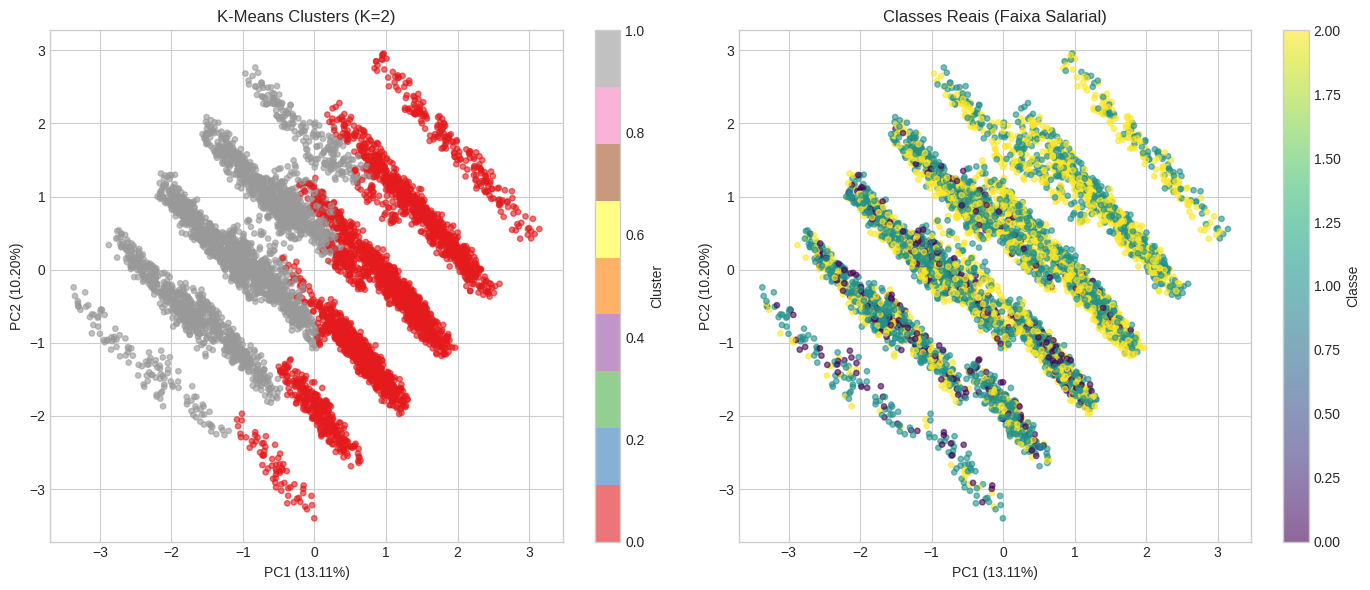


Distribuição de Classes por Cluster:
salary    0     1     2   All
row_0                        
0       191  1514  1504  3209
1       329  1628  1041  2998
All     520  3142  2545  6207

Modelos não supervisionados salvos!


In [293]:
# PCA 2D para visualização
pca_2d = PCA(n_components=2, random_state=SEED)
X_pca_2d = pca_2d.fit_transform(X_train_processed)

# Clusters finais
kmeans_final = KMeans(n_clusters=N_CLUSTERS, random_state=SEED, n_init=10)
clusters = kmeans_final.fit_predict(X_train_processed)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Por cluster
scatter1 = axes[0].scatter(X_pca_2d[:, 0], X_pca_2d[:, 1], c=clusters, cmap='Set1', alpha=0.6, s=15)
axes[0].set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]:.2%})')
axes[0].set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]:.2%})')
axes[0].set_title(f'K-Means Clusters (K={N_CLUSTERS})')
plt.colorbar(scatter1, ax=axes[0], label='Cluster')

# Por classe real
scatter2 = axes[1].scatter(X_pca_2d[:, 0], X_pca_2d[:, 1], c=y_train, cmap='viridis', alpha=0.6, s=15)
axes[1].set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]:.2%})')
axes[1].set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]:.2%})')
axes[1].set_title('Classes Reais (Faixa Salarial)')
plt.colorbar(scatter2, ax=axes[1], label='Classe')

plt.tight_layout()
plt.savefig('../reports/clusters_vs_classes.png', dpi=150, bbox_inches='tight')
plt.show()

# Tabela de correspondência cluster vs classe
print("\nDistribuição de Classes por Cluster:")
cluster_class_dist = pd.crosstab(clusters, y_train, margins=True)
print(cluster_class_dist)

# Salvar modelo
joblib.dump(kmeans_final, '../models/kmeans_integrated.joblib')
joblib.dump(pca_2d, '../artifacts/pca_2d.joblib')
print("\nModelos não supervisionados salvos!")

---
## 8.Avaliação Final Conjunto de Testes

**Atenção:** Esta seção é executada **APENAS UMA VEZ** após toda a seleção e otimização de modelos.  
O conjunto de teste não foi utilizado em nenhum momento durante o desenvolvimento.  
Esta é a métrica que reportamos como desempenho real do modelo.

RESULTADO FINAL NO CONJUNTO DE TESTE
Modelo: Random Forest (Otimizado via Optuna)

Acurácia:              0.9787
Acurácia Balanceada:   0.9703
Precisão Macro:        0.9847
Recall Macro:          0.9703
F1-Score Macro:        0.9773  (métrica principal)
F1-Score Weighted:     0.9787

CLASSIFICATION REPORT (TESTE)
              precision    recall  f1-score   support

       Baixo       1.00      0.95      0.97       173
       Medio       0.98      0.98      0.98      1048
        Alto       0.98      0.98      0.98       848

    accuracy                           0.98      2069
   macro avg       0.98      0.97      0.98      2069
weighted avg       0.98      0.98      0.98      2069


MATRIZ DE CONFUSÃO FINAL (TESTE)


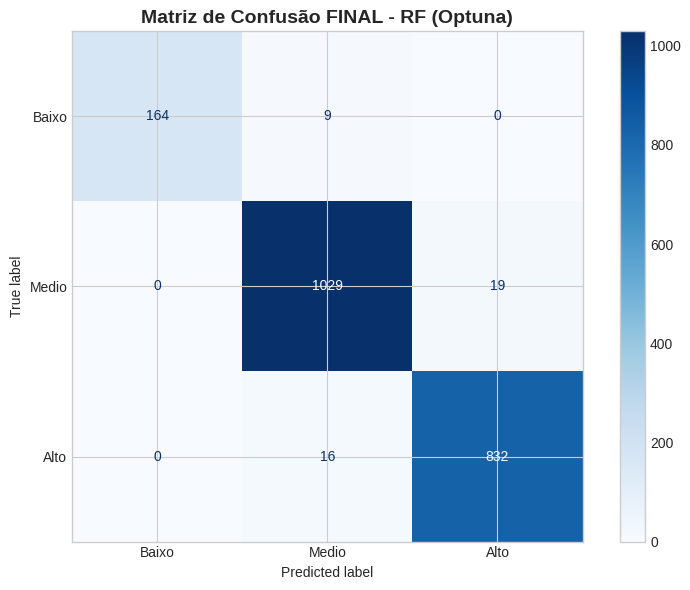

       Baixo  Medio  Alto
Baixo    164      9     0
Medio      0   1029    19
Alto       0     16   832

✓ Pipeline final salvo em: models/final_pipeline.joblib


In [294]:
# ===========================================================================
# AVALIAÇÃO FINAL NO CONJUNTO DE TESTE (APENAS UMA VEZ!)
# ===========================================================================
# Usar o melhor modelo encontrado (Optuna ou GridSearch)
# Pipeline com preprocessador para manter consistência metodológica

# Criar Pipeline final com preprocessador + modelo otimizado
final_pipeline = Pipeline([
    ('preprocessor', create_preprocessor()),
    ('classifier', RandomForestClassifier(**best_params, random_state=SEED, n_jobs=-1))
])

# Treinar no conjunto de treino completo (X_train RAW)
final_pipeline.fit(X_train, y_train)

# AVALIAÇÃO NO CONJUNTO DE TESTE (única vez!)
y_test_pred_final = final_pipeline.predict(X_test)
y_test_proba_final = final_pipeline.predict_proba(X_test)

# Métricas finais completas (conforme enunciado)
test_accuracy = accuracy_score(y_test, y_test_pred_final)
test_balanced_acc = balanced_accuracy_score(y_test, y_test_pred_final)
test_precision_macro = precision_score(y_test, y_test_pred_final, average='macro', zero_division=0)
test_recall_macro = recall_score(y_test, y_test_pred_final, average='macro', zero_division=0)
test_f1_macro = f1_score(y_test, y_test_pred_final, average='macro')
test_f1_weighted = f1_score(y_test, y_test_pred_final, average='weighted')

print("="*60)
print(f"RESULTADO FINAL NO CONJUNTO DE TESTE")
print(f"Modelo: Random Forest (Otimizado via {best_strategy})")
print("="*60)
print(f"\nAcurácia:              {test_accuracy:.4f}")
print(f"Acurácia Balanceada:   {test_balanced_acc:.4f}")
print(f"Precisão Macro:        {test_precision_macro:.4f}")
print(f"Recall Macro:          {test_recall_macro:.4f}")
print(f"F1-Score Macro:        {test_f1_macro:.4f}  (métrica principal)")
print(f"F1-Score Weighted:     {test_f1_weighted:.4f}")

print("\n" + "="*60)
print("CLASSIFICATION REPORT (TESTE)")
print("="*60)
print(classification_report(y_test, y_test_pred_final,
                            target_names=[target_mapping[i] for i in range(len(target_mapping))]))

# Matriz de Confusão Final
print("\n" + "="*60)
print("MATRIZ DE CONFUSÃO FINAL (TESTE)")
print("="*60)
cm_test = confusion_matrix(y_test, y_test_pred_final)
class_names = [target_mapping[i] for i in range(len(target_mapping))]

fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_test, display_labels=class_names)
disp.plot(ax=ax, cmap='Blues', values_format='d')
plt.title(f'Matriz de Confusão FINAL - RF ({best_strategy})', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/confusion_matrix_test_FINAL.png', dpi=150, bbox_inches='tight')
plt.show()

print(pd.DataFrame(cm_test, index=class_names, columns=class_names))

# Salvar pipeline final
joblib.dump(final_pipeline, '../models/final_pipeline.joblib')
print(f"\n✓ Pipeline final salvo em: models/final_pipeline.joblib")

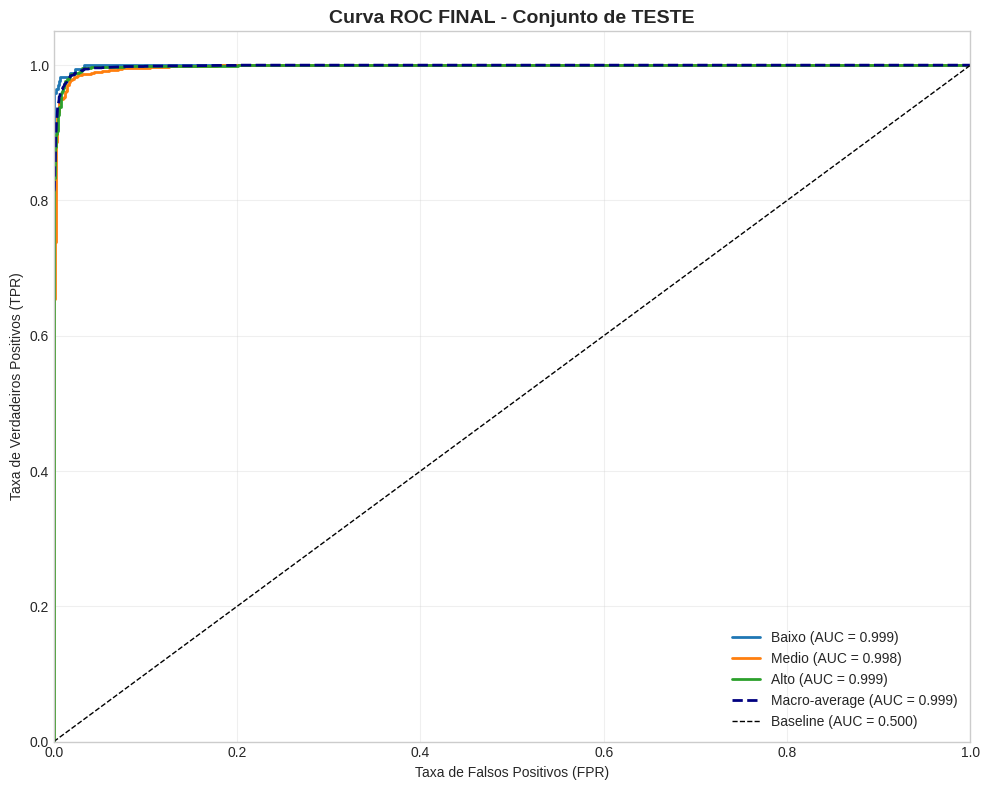


📊 AUC por classe (TESTE FINAL):
  Baixo: 0.9995
  Medio: 0.9976
  Alto: 0.9985

🎯 AUC Macro (TESTE): 0.9986

✅ Modelo final salvo em: models/final_model_optimized.joblib


In [295]:
# Curva ROC Final no Conjunto de Teste
n_classes = len(target_mapping)
y_test_bin = label_binarize(y_test, classes=[0, 1, 2])

# ROC para cada classe
fpr_test = {}
tpr_test = {}
roc_auc_test = {}

for i in range(n_classes):
    fpr_test[i], tpr_test[i], _ = roc_curve(y_test_bin[:, i], y_test_proba_final[:, i])
    roc_auc_test[i] = auc(fpr_test[i], tpr_test[i])

# ROC macro
all_fpr_test = np.unique(np.concatenate([fpr_test[i] for i in range(n_classes)]))
mean_tpr_test = np.zeros_like(all_fpr_test)
for i in range(n_classes):
    mean_tpr_test += np.interp(all_fpr_test, fpr_test[i], tpr_test[i])
mean_tpr_test /= n_classes
roc_auc_macro_test = auc(all_fpr_test, mean_tpr_test)

# Plot
plt.figure(figsize=(10, 8))
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']

for i, color in enumerate(colors):
    plt.plot(fpr_test[i], tpr_test[i], color=color, lw=2,
             label=f'{class_names[i]} (AUC = {roc_auc_test[i]:.3f})')

plt.plot(all_fpr_test, mean_tpr_test, color='navy', lw=2, linestyle='--',
         label=f'Macro-average (AUC = {roc_auc_macro_test:.3f})')
plt.plot([0, 1], [0, 1], 'k--', lw=1, label='Baseline (AUC = 0.500)')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Taxa de Falsos Positivos (FPR)')
plt.ylabel('Taxa de Verdadeiros Positivos (TPR)')
plt.title('Curva ROC FINAL - Conjunto de TESTE', fontsize=14, fontweight='bold')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../reports/roc_curve_test_FINAL.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n📊 AUC por classe (TESTE FINAL):")
for i, name in enumerate(class_names):
    print(f"  {name}: {roc_auc_test[i]:.4f}")
print(f"\n🎯 AUC Macro (TESTE): {roc_auc_macro_test:.4f}")

# Salvar modelo final
joblib.dump(final_pipeline, '../models/final_model_optimized.joblib')
print(f"\n✅ Modelo final salvo em: models/final_model_optimized.joblib")

---
## 9. Conclusões

In [296]:
# Resumo final dos resultados
print("="*60)
print("RESUMO DO PROJETO")
print("="*60)

print("\n1. DATASET")
print(f"   - Total de registros: {len(df):,}")
print(f"   - Total de features: {X.shape[1]}")
print(f"   - Features após encoding: {X_train_processed.shape[1]}")
print(f"   - Split: 60% treino / 20% validação / 20% teste")

print("\n2. MODELAGEM SUPERVISIONADA")
print(f"   Melhor modelo: Random Forest (Otimizado via {best_strategy})")
print(f"   - F1-macro (validação CV): {best_cv_score:.4f}")
print(f"   - F1-macro (TESTE FINAL): {test_f1_macro:.4f}")
print(f"   - Acurácia (TESTE FINAL): {test_accuracy:.4f}")
print(f"   - AUC Macro (TESTE FINAL): {roc_auc_macro_test:.4f}")

print("\n3. MODELAGEM NÃO SUPERVISIONADA")
print(f"   - K-Means: K selecionado por fold (moda: {N_CLUSTERS})")

print("\n4. METODOLOGIA")
print("   ✓ Conjunto de teste usado APENAS na avaliação final")
print("   ✓ Seleção de modelo via validação cruzada no treino")
print("   ✓ Preprocessador dentro do pipeline para evitar data leakage")
print("   ✓ K do K-Means selecionado dentro de cada fold")

print("\n5. ARTEFATOS SALVOS")
print("   - models/final_model_optimized.joblib (modelo final)")
print("   - models/best_random_forest.joblib")
print("   - artifacts/preprocessor.joblib")

RESUMO DO PROJETO

1. DATASET
   - Total de registros: 10,345
   - Total de features: 17
   - Features após encoding: 34
   - Split: 60% treino / 20% validação / 20% teste

2. MODELAGEM SUPERVISIONADA
   Melhor modelo: Random Forest (Otimizado via Optuna)
   - F1-macro (validação CV): 0.9714
   - F1-macro (TESTE FINAL): 0.9773
   - Acurácia (TESTE FINAL): 0.9787
   - AUC Macro (TESTE FINAL): 0.9986

3. MODELAGEM NÃO SUPERVISIONADA
   - K-Means: K selecionado por fold (moda: 2)

4. METODOLOGIA
   ✓ Conjunto de teste usado APENAS na avaliação final
   ✓ Seleção de modelo via validação cruzada no treino
   ✓ Preprocessador dentro do pipeline para evitar data leakage
   ✓ K do K-Means selecionado dentro de cada fold

5. ARTEFATOS SALVOS
   - models/final_model_optimized.joblib (modelo final)
   - models/best_random_forest.joblib
   - artifacts/preprocessor.joblib


In [297]:
# Validação cruzada final do melhor modelo (com Pipeline para evitar data leakage)
print("\nValidação Cruzada (5-fold) do Melhor Modelo:")

# Criar pipeline com os melhores parâmetros
final_pipeline = Pipeline([
    ('preprocessor', create_preprocessor()),
    ('classifier', RandomForestClassifier(**best_params, random_state=SEED, n_jobs=-1))
])

cv_scores = cross_val_score(final_pipeline, X_train, y_train, cv=5, scoring='f1_macro')
print(f"  F1-macro médio: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")


Validação Cruzada (5-fold) do Melhor Modelo:
  F1-macro médio: 0.9684 (+/- 0.0047)


### Limitações e Próximos Passos

**Limitações identificadas:**
1. Dataset possivelmente sintético (valores muito regulares, anos futuros como 2026)
2. Inconsistências nos dados (Entry-level com 14 anos de experiência)
3. Não há informações sobre benefícios, localização específica ou tipo de contrato

**Possíveis melhorias:**
1. Feature engineering adicional (ex: combinar skills em índice)
2. Testar outros modelos (LightGBM, CatBoost)
3. Análise de resíduos mais detalhada
4. Validar com dados reais do mercado